# Prediccion opcion de pago

## Analisis inicial de data disponible

In [73]:
import pandas as pd
# Metadata del dataset
df = pd.read_excel("../data/Metadata.xlsx")
df.head()

,name,type,comment
0,nit_enmascarado,bigint,numero identificador del cliente enmascarado
1,num_oblig_orig_enmascarado,bigint,Numero identificador de obligacion original de...
2,num_oblig_enmascarado,bigint,Numero identificador de obligacion actual
3,fecha_var_rpta_alt,bigint,Fecha mes de la variable respuesta
4,var_rpta_alt,tinyint,Valor de la variable respuesta 1: acepto opcio...


In [74]:
#  lista de clientes y obligaciones a calificar en 2024/01
oot = pd.read_csv("../data/prueba_op_base_pivot_var_rpta_alt_enmascarado_oot.csv")
oot.head()

,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha_var_rpta_alt
0,257335,444821,635511,202401
1,59584,350400,730364,202401
2,397604,973821,106521,202401
3,368086,382995,696856,202401
4,255009,434238,645924,202401


In [75]:
# Información de variable objetivo para train
trtest = pd.read_csv("../data/prueba_op_base_pivot_var_rpta_alt_enmascarado_trtest.csv")
trtest.head()

,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha_var_rpta_alt,var_rpta_alt,tipo_var_rpta_alt,banca,segmento,producto,producto_cons,...,porc_pago_cuota,pago_mes,porc_pago_mes,pagos_tanque,marca_debito_mora,alternativa_aplicada_agr,marca_agrupada_rgo,marca_pago,marca_alternativa,marca_alternativa_orig
0,630611,219718,863073,202308,1,a_uno_tipo_1,Banca Personas,Personal,TARJETA DE CREDITO,Tarjeta de Credito,...,0.095438,0.0,0.000000,Sin pago,NO,CONSOLIDACION,REESTRUCTURACIÓN,Sin pago,Acepta Alternativa,Acepta Alternativa
1,59412,789567,290775,202312,1,a_uno_tipo_1,Banca Personas,Personal,LIBRE INVERSION,Libre Inversion,...,0.000000,0.0,NaN,Sin pago,NO,PRORROGA,MANTENIMIENTO,Sin pago,Acepta Alternativa,Acepta Alternativa
2,277595,1045909,34433,202312,1,b_uno_tipo_2,Banca Personas,Personal,LIBRE INVERSION,Libre Inversion,...,0.000000,0.0,NaN,Sin pago,NO,NaN,NaN,Sin pago,Acepta Alternativa,Acepta Alternativa
3,26897,585786,494556,202311,1,a_uno_tipo_1,Banca Personas,Personal,ROTATIVOS,Rotativos,...,0.042117,4090.0,0.015324,Con pago,NO,PRORROGA,MANTENIMIENTO,Pago parcial,Acepta Alternativa,Acepta Alternativa
4,24588,1061389,18953,202311,1,b_uno_tipo_2,Banca Personas,Personal plus,ROTATIVOS,Rotativos,...,0.000000,0.0,0.000000,Sin pago,NO,CONSOLIDACION,REESTRUCTURACIÓN,Sin pago,Acepta Alternativa,Acepta Alternativa


In [76]:
# información de pagos obligaciones
maestra_cuota = pd.read_csv("../data/prueba_op_maestra_cuotas_pagos_mes_hist_enmascarado_completa.csv")
maestra_cuota.head()

,nit_enmascarado,num_oblig_enmascarado,fecha_corte,producto,aplicativo,segmento,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,marca_pago,ajustes_banco
0,482906,362297,20230731,CARTERA MICROCREDITO,L,MICROPYME,311950.0,1862788.0,20230621.0,20230721.0,597.0,PAGO_MENOS,NO
1,121735,186855,20230228,LIBRE INVERSION,L,SOCIAL,131030.0,264157.0,20230127.0,20230207.0,202.0,PAGO_MENOS,NO
2,582719,675503,20231031,TARJETA DE CREDITO,K,PERSONAL,1405339.0,3320.0,20231003.0,20231003.0,0.0,PAGO_MENOS,NO
3,299903,107931,20230228,ROTATIVOS,L,PERSONAL PLUS,19220.0,0.0,NaN,NaN,0.0,FACTURACION_MES_SGTE,NO
4,88625,566060,20230430,ROTATIVOS,L,PERSONAL,384684.0,769368.0,20230403.0,20230403.0,200.0,PAGO_MAS,NO


In [77]:
#  información demográfica cliente
master_customer_data = pd.read_csv("../data/prueba_op_master_customer_data_enmascarado_completa.csv")
master_customer_data.head()

,nit_enmascarado,cod_tipo_doc,tipo_cli,ctrl_terc,genero_cli,ano_nac_cli,edad_cli,estado_civil,tipo_vivienda,num_hijos,...,nicho,region_of,nombre_dpto_dirp,egresos_mes,tot_patrimonio,ciiu,smmlv,year,month,ingestion_day
0,536377,1,PERSONA NATURAL,CLIENTE,F,1998.0,25.0,SOLTERO,FAMILIAR,0.0,...,MUJERES,CENTRO,SANTANDER,0.0,33750000.0,NaN,1160000.0,2023,12,31
1,512257,1,PERSONA NATURAL,CLIENTE,F,1984.0,38.0,UNION LIBRE,PROPIA,0.0,...,MUJERES,CARIBE,MAGDALENA,250000.0,5000000.0,ASALARIADOS,1160000.0,2023,9,30
2,5788,1,PERSONA NATURAL,CLIENTE SOCIAL,M,1960.0,63.0,NaN,NaN,0.0,...,NaN,DIRECCIÓN GENERAL,SIN INFORMACION,0.0,0.0,ASALARIADOS,1160000.0,2023,11,30
3,132245,1,PERSONA NATURAL,CLIENTE,F,1982.0,41.0,CASADO,NaN,1.0,...,MUJERES,SUR,VALLE,1000000.0,62513000.0,ASALARIADOS,1160000.0,2023,7,31
4,245279,1,PERSONA NATURAL,CLIENTE,M,1980.0,43.0,CASADO,ALQUILADA,0.0,...,NaN,BOGOTA Y CUNDINAMARCA,CALDAS,1000000.0,34135000.0,ASALARIADOS,1160000.0,2023,12,31


In [78]:
#  Información de probabilidades de modelos desarrollados
probabilidad_oblig = pd.read_csv("../data/prueba_op_probabilidad_oblig_base_hist_enmascarado_completa.csv")
probabilidad_oblig.head()

,nit_enmascarado,num_oblig_enmascarado,fecha_corte,lote,prob_propension,prob_alrt_temprana,prob_auto_cura
0,296482,102381,202308,1,0.761350,0.193744,0.684784
1,391957,742315,202310,2,0.741803,0.384184,0.483696
2,229894,359919,202307,1,0.835373,0.285157,0.826225
3,478963,239064,202303,3,0.445002,0.629652,0.346508
4,349609,923348,202308,2,0.784365,0.419123,0.667603


In [79]:
#  Una muestra de cómo debería ser el archivo de sumisión Este archivo tiene una columna ID que se compone de 
# las columnas nit_enmascarado, num_oblig_orig_enmascarado, num_oblig_enmascarado concatenado por el caracter 
# "#"
sample = pd.read_csv("../data/sample_submission.csv")
sample.head()

,ID,var_rpta_alt
0,243031#516680#563662,1
1,401665#347465#733256,0
2,391362#511160#569182,0
3,169789#441265#639051,0
4,341343#76559#1028512,0


## Analisis de maestra_cuota

In [80]:
# Analisis maestra_cuota
maestra_cuota

,nit_enmascarado,num_oblig_enmascarado,fecha_corte,producto,aplicativo,segmento,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,marca_pago,ajustes_banco
0,482906,362297,20230731,CARTERA MICROCREDITO,L,MICROPYME,311950.0,1862788.0,20230621.0,20230721.0,597.0,PAGO_MENOS,NO
1,121735,186855,20230228,LIBRE INVERSION,L,SOCIAL,131030.0,264157.0,20230127.0,20230207.0,202.0,PAGO_MENOS,NO
2,582719,675503,20231031,TARJETA DE CREDITO,K,PERSONAL,1405339.0,3320.0,20231003.0,20231003.0,0.0,PAGO_MENOS,NO
3,299903,107931,20230228,ROTATIVOS,L,PERSONAL PLUS,19220.0,0.0,NaN,NaN,0.0,FACTURACION_MES_SGTE,NO
4,88625,566060,20230430,ROTATIVOS,L,PERSONAL,384684.0,769368.0,20230403.0,20230403.0,200.0,PAGO_MAS,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4855030,428347,628599,20231130,TARJETA DE CREDITO,K,PERSONAL,320992.0,640523.0,20231120.0,20231120.0,200.0,FACTURACION_MES_SGTE,NO
4855031,356568,606593,20230228,HIPOTECARIO VIVIENDA,4,PERSONAL,814754.0,2308770.0,20230201.0,20230201.0,283.0,PAGO_MAS,NO
4855032,234904,500584,20230930,LIBRE INVERSION,L,PERSONAL,315738.0,0.0,NaN,NaN,0.0,IGUAL,NO
4855033,447934,12846,20231231,LIBRE INVERSION,L,PERSONAL PLUS,5317285.0,89289.0,20231108.0,20231108.0,2.0,PAGO_MENOS,NO


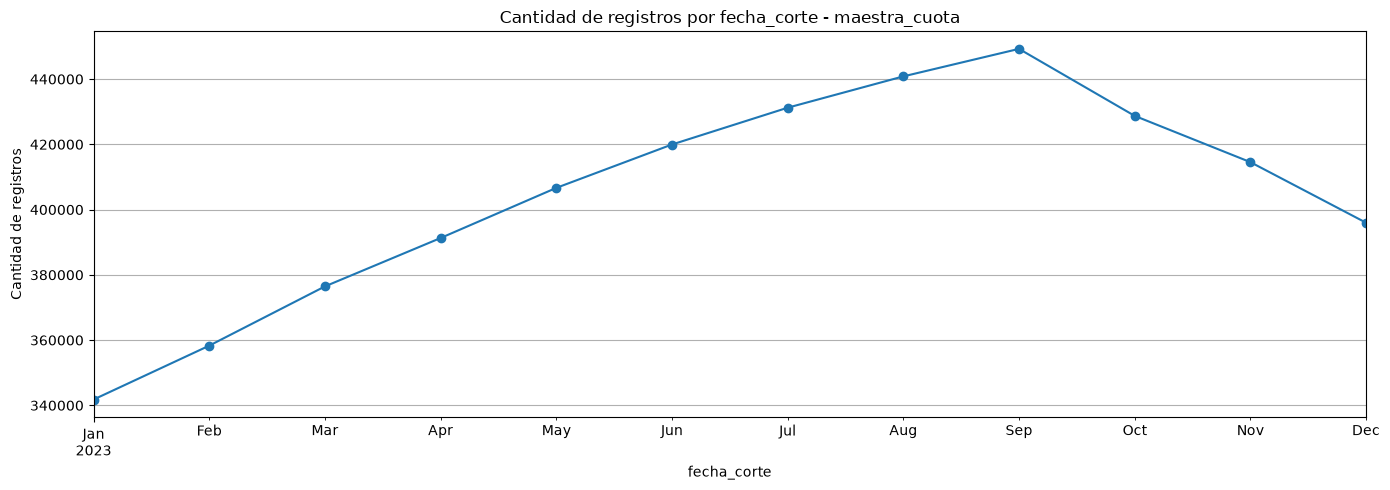

In [81]:
import matplotlib.pyplot as plt

# Conteo de registros por fecha_corte
fecha_corte_counts = (
    maestra_cuota["fecha_corte"]
    .astype(str)
    .pipe(pd.to_datetime, format="%Y%m%d")
    .value_counts()
    .sort_index()   
)

plt.figure(figsize=(14, 5))
fecha_corte_counts.plot(kind="line", marker="o")
plt.title("Cantidad de registros por fecha_corte - maestra_cuota")
plt.xlabel("fecha_corte")
plt.ylabel("Cantidad de registros")
plt.grid(True)
plt.tight_layout()
plt.show()


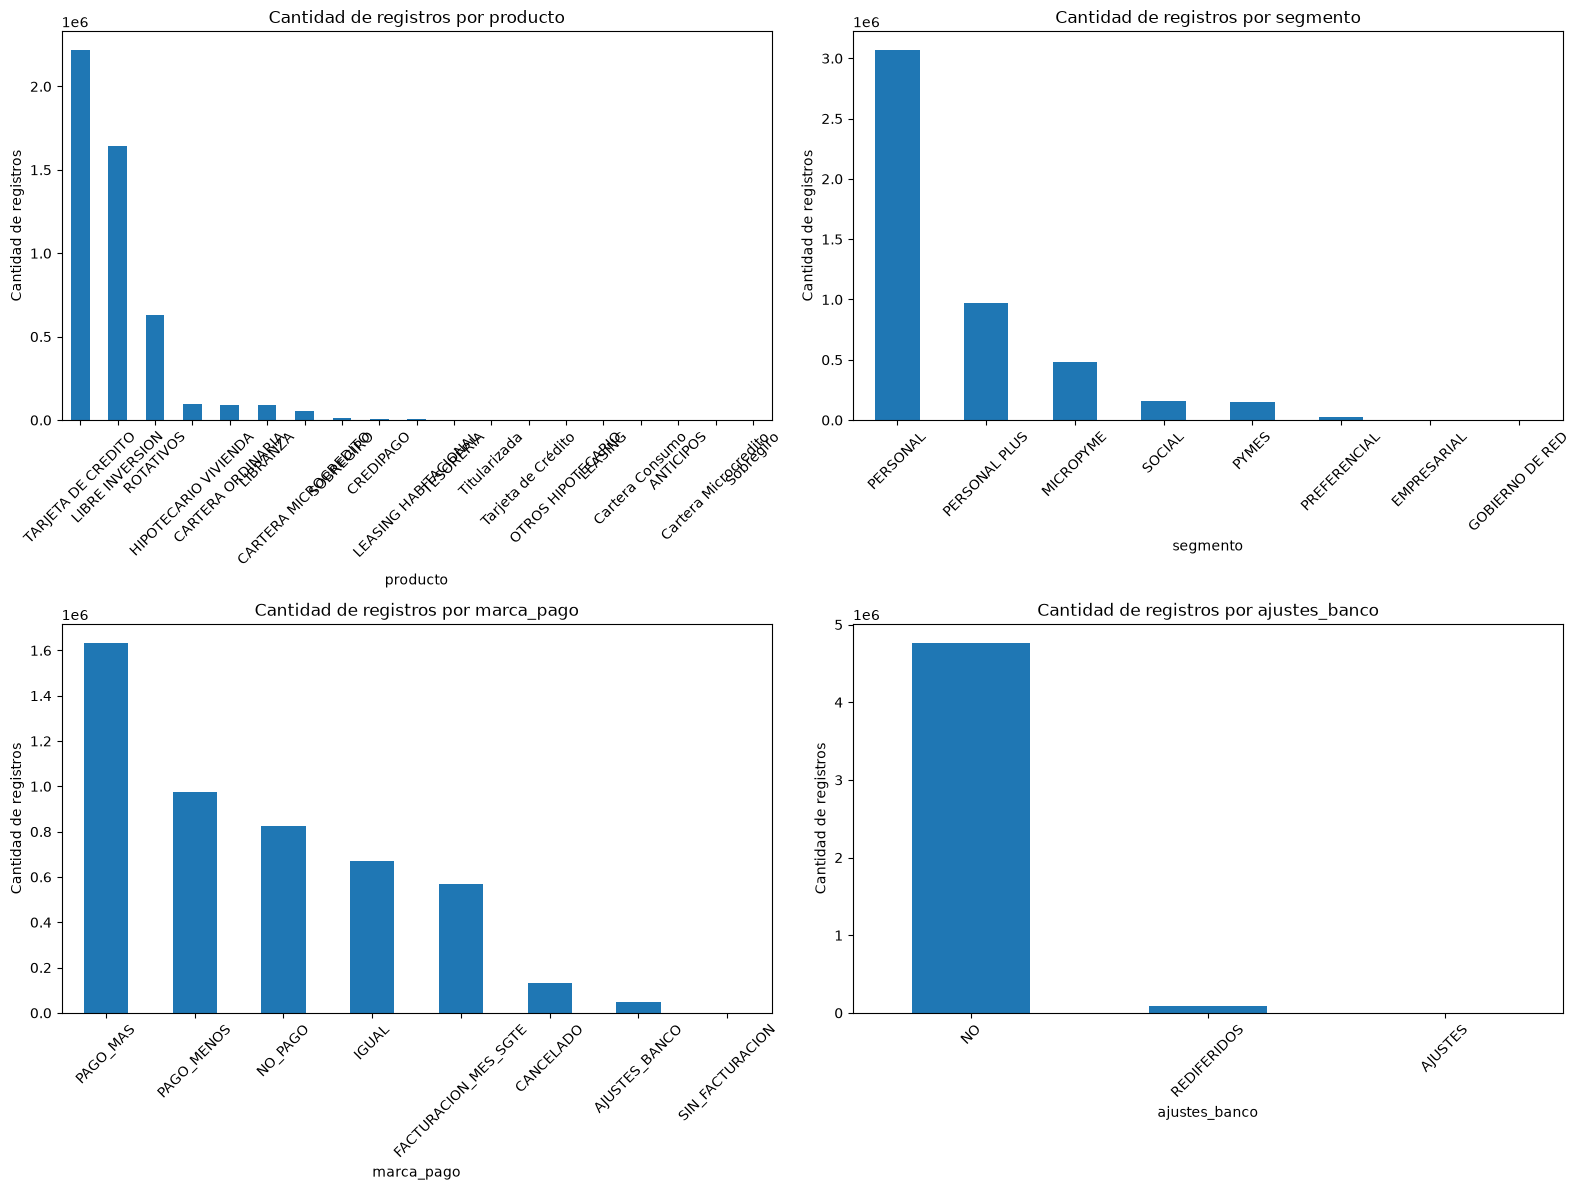

In [82]:
columnas_categoricas = ["producto", "segmento", "marca_pago", "ajustes_banco"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, columna in zip(axes.flatten(), columnas_categoricas):
    conteo = maestra_cuota[columna].value_counts().sort_values(ascending=False)
    conteo.plot(kind="bar", ax=ax)
    ax.set_title(f"Cantidad de registros por {columna}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Cantidad de registros")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


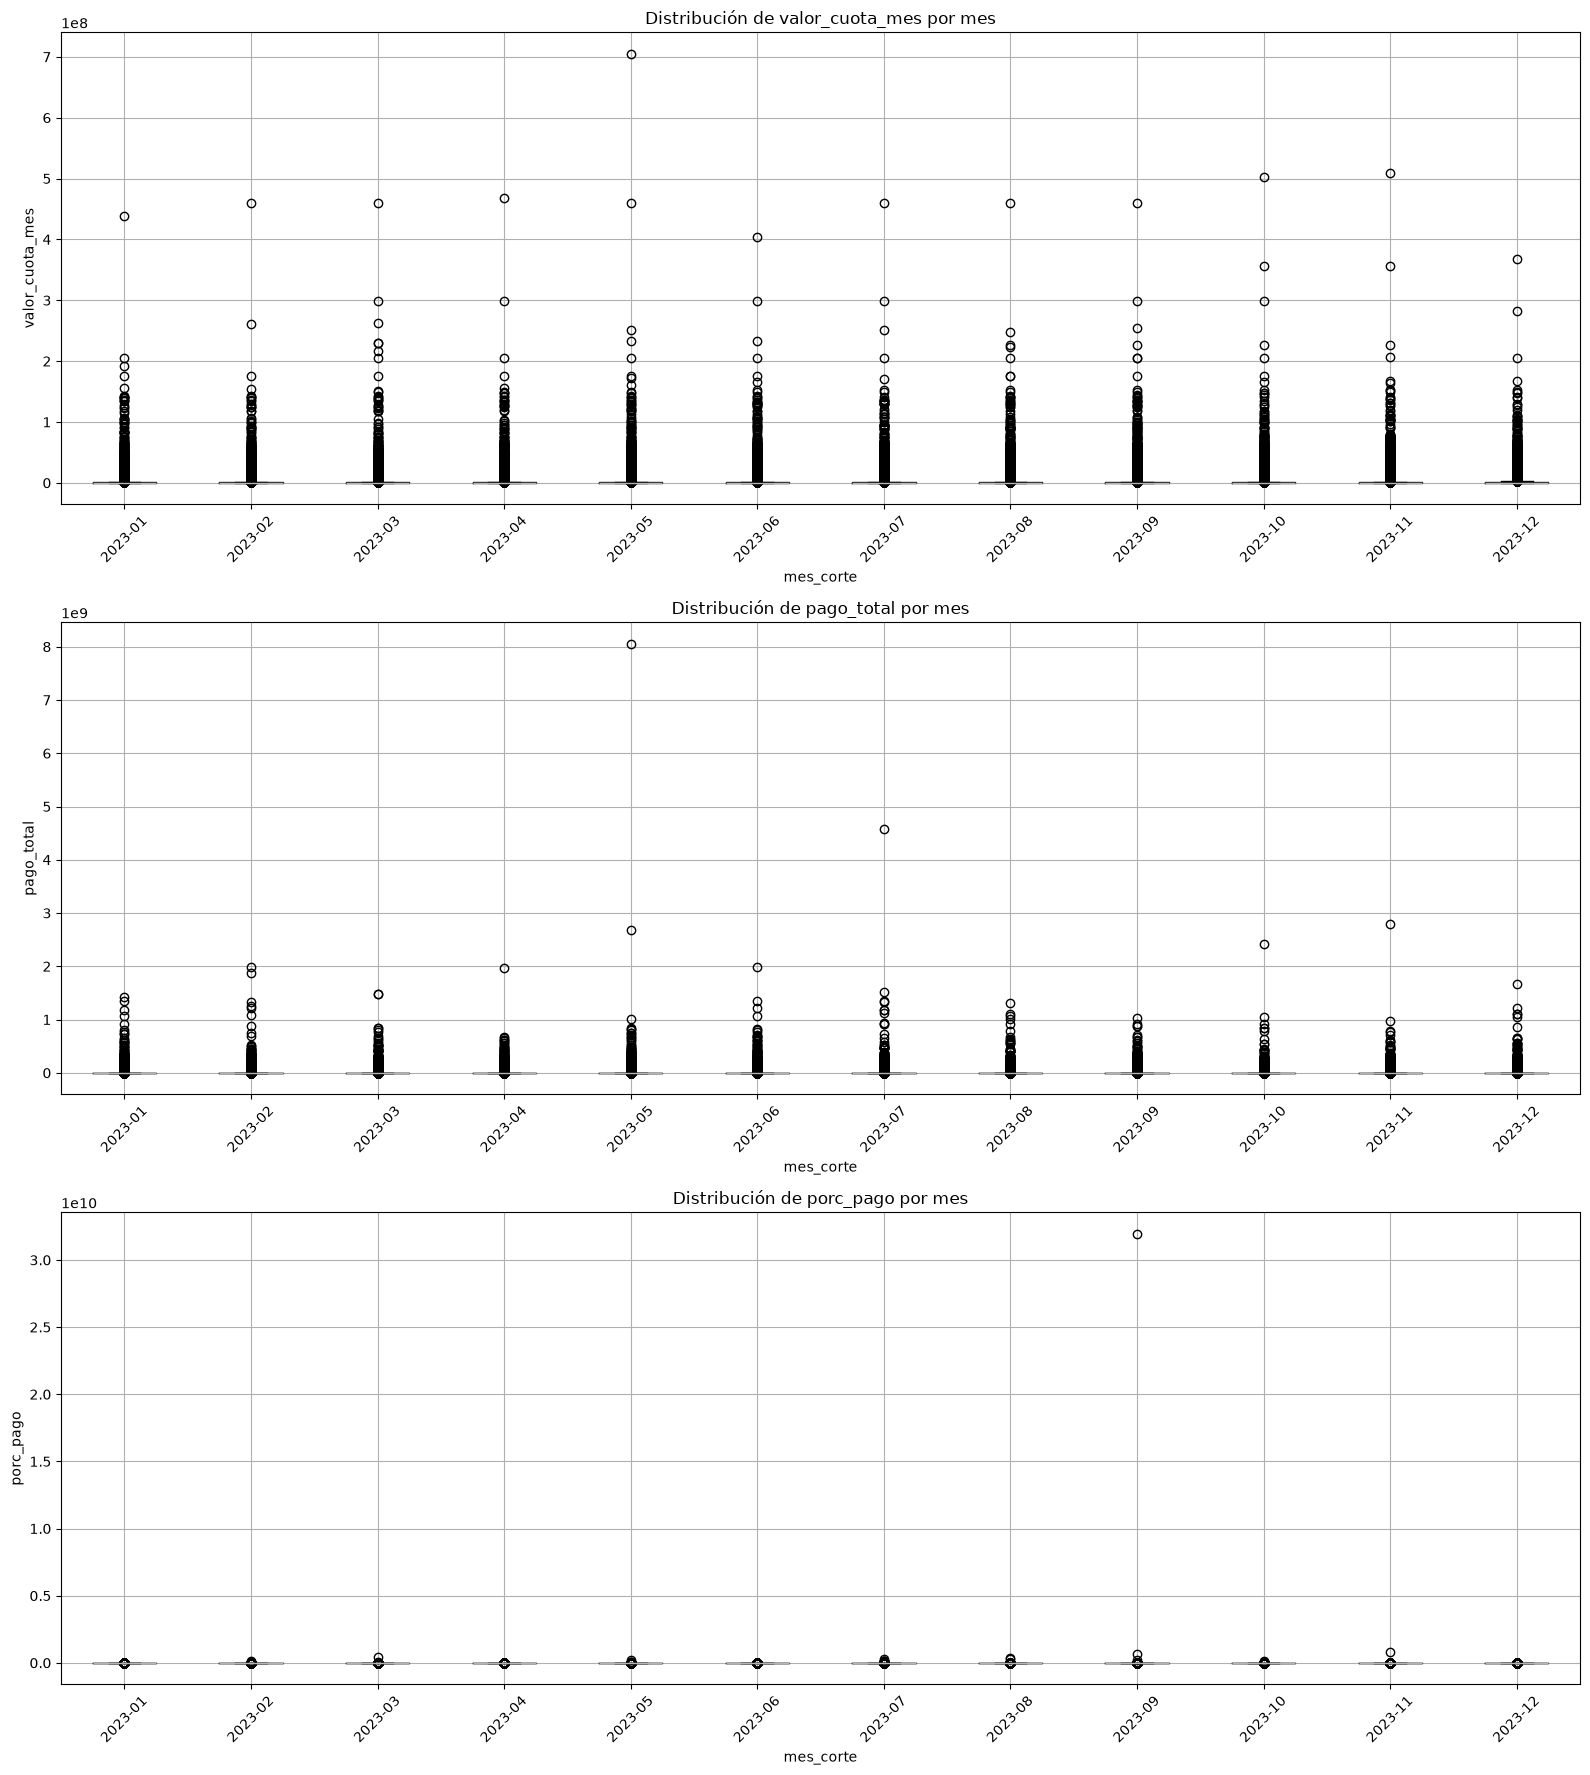

In [83]:
maestra_cuota["mes_corte"] = pd.to_datetime(
    maestra_cuota["fecha_corte"].astype(str), format="%Y%m%d"
).dt.to_period("M").astype(str)

columnas_numericas = ["valor_cuota_mes", "pago_total", "porc_pago"]

fig, axes = plt.subplots(len(columnas_numericas), 1, figsize=(16, 18))

for ax, columna in zip(axes, columnas_numericas):
    maestra_cuota.boxplot(column=columna, by="mes_corte", ax=ax, rot=45)
    ax.set_title(f"Distribución de {columna} por mes")
    ax.set_xlabel("mes_corte")
    ax.set_ylabel(columna)

plt.suptitle("")
plt.tight_layout()
plt.show()


In [84]:
columnas = ["producto", "segmento", "marca_pago", "ajustes_banco", "valor_cuota_mes", "pago_total", 
                        "porc_pago"]
nulos_por_mes = (
    maestra_cuota.groupby("mes_corte")[columnas]
    .apply(lambda grupo: grupo.isnull().sum())
)

nulos_por_mes


,producto,segmento,marca_pago,ajustes_banco,valor_cuota_mes,pago_total,porc_pago
mes_corte,,,,,,,
2023-01,0,0,0,0,0,0,7964
2023-02,0,0,0,0,0,0,7899
2023-03,0,0,0,0,0,0,7935
2023-04,0,0,0,0,0,0,6517
2023-05,0,0,0,0,0,0,5780
2023-06,0,0,0,0,0,0,4738
2023-07,0,0,0,0,0,0,4305
2023-08,0,0,0,0,0,0,3261
2023-09,0,0,0,0,0,0,8104


## master_customer_data

In [85]:
master_customer_data.keys()

Index(['nit_enmascarado', 'cod_tipo_doc', 'tipo_cli', 'ctrl_terc',
       'genero_cli', 'ano_nac_cli', 'edad_cli', 'estado_civil',
       'tipo_vivienda', 'num_hijos', 'personas_dependientes',
       'nivel_academico', 'ocup', 'act_econom', 'sector', 'subsector',
       'declarante', 'total_ing', 'tot_activos', 'tot_pasivos',
       'origen_fondos', 'f_vinc', 'f_ult_mantenimiento', 'canal_actualizacion',
       'cli_actualizado', 'segm', 'subsegm', 'nicho', 'region_of',
       'nombre_dpto_dirp', 'egresos_mes', 'tot_patrimonio', 'ciiu', 'smmlv',
       'year', 'month', 'ingestion_day'],
      dtype='str')

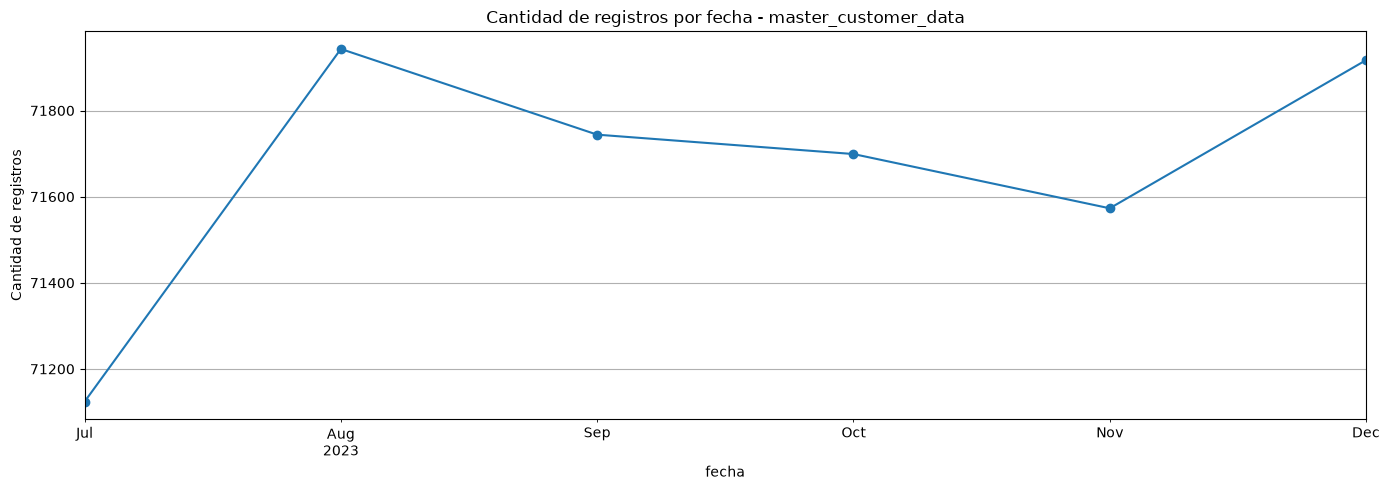

In [86]:
# Conteo de registros por fecha, construida a partir de year, month e ingestion_day
fecha_corte_counts = (
    pd.to_datetime(
        master_customer_data[["year", "month", "ingestion_day"]]
        .rename(columns={"ingestion_day": "day"})
    )
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14, 5))
fecha_corte_counts.plot(kind="line", marker="o")
plt.title("Cantidad de registros por fecha - master_customer_data")
plt.xlabel("fecha")
plt.ylabel("Cantidad de registros")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\2482591935.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


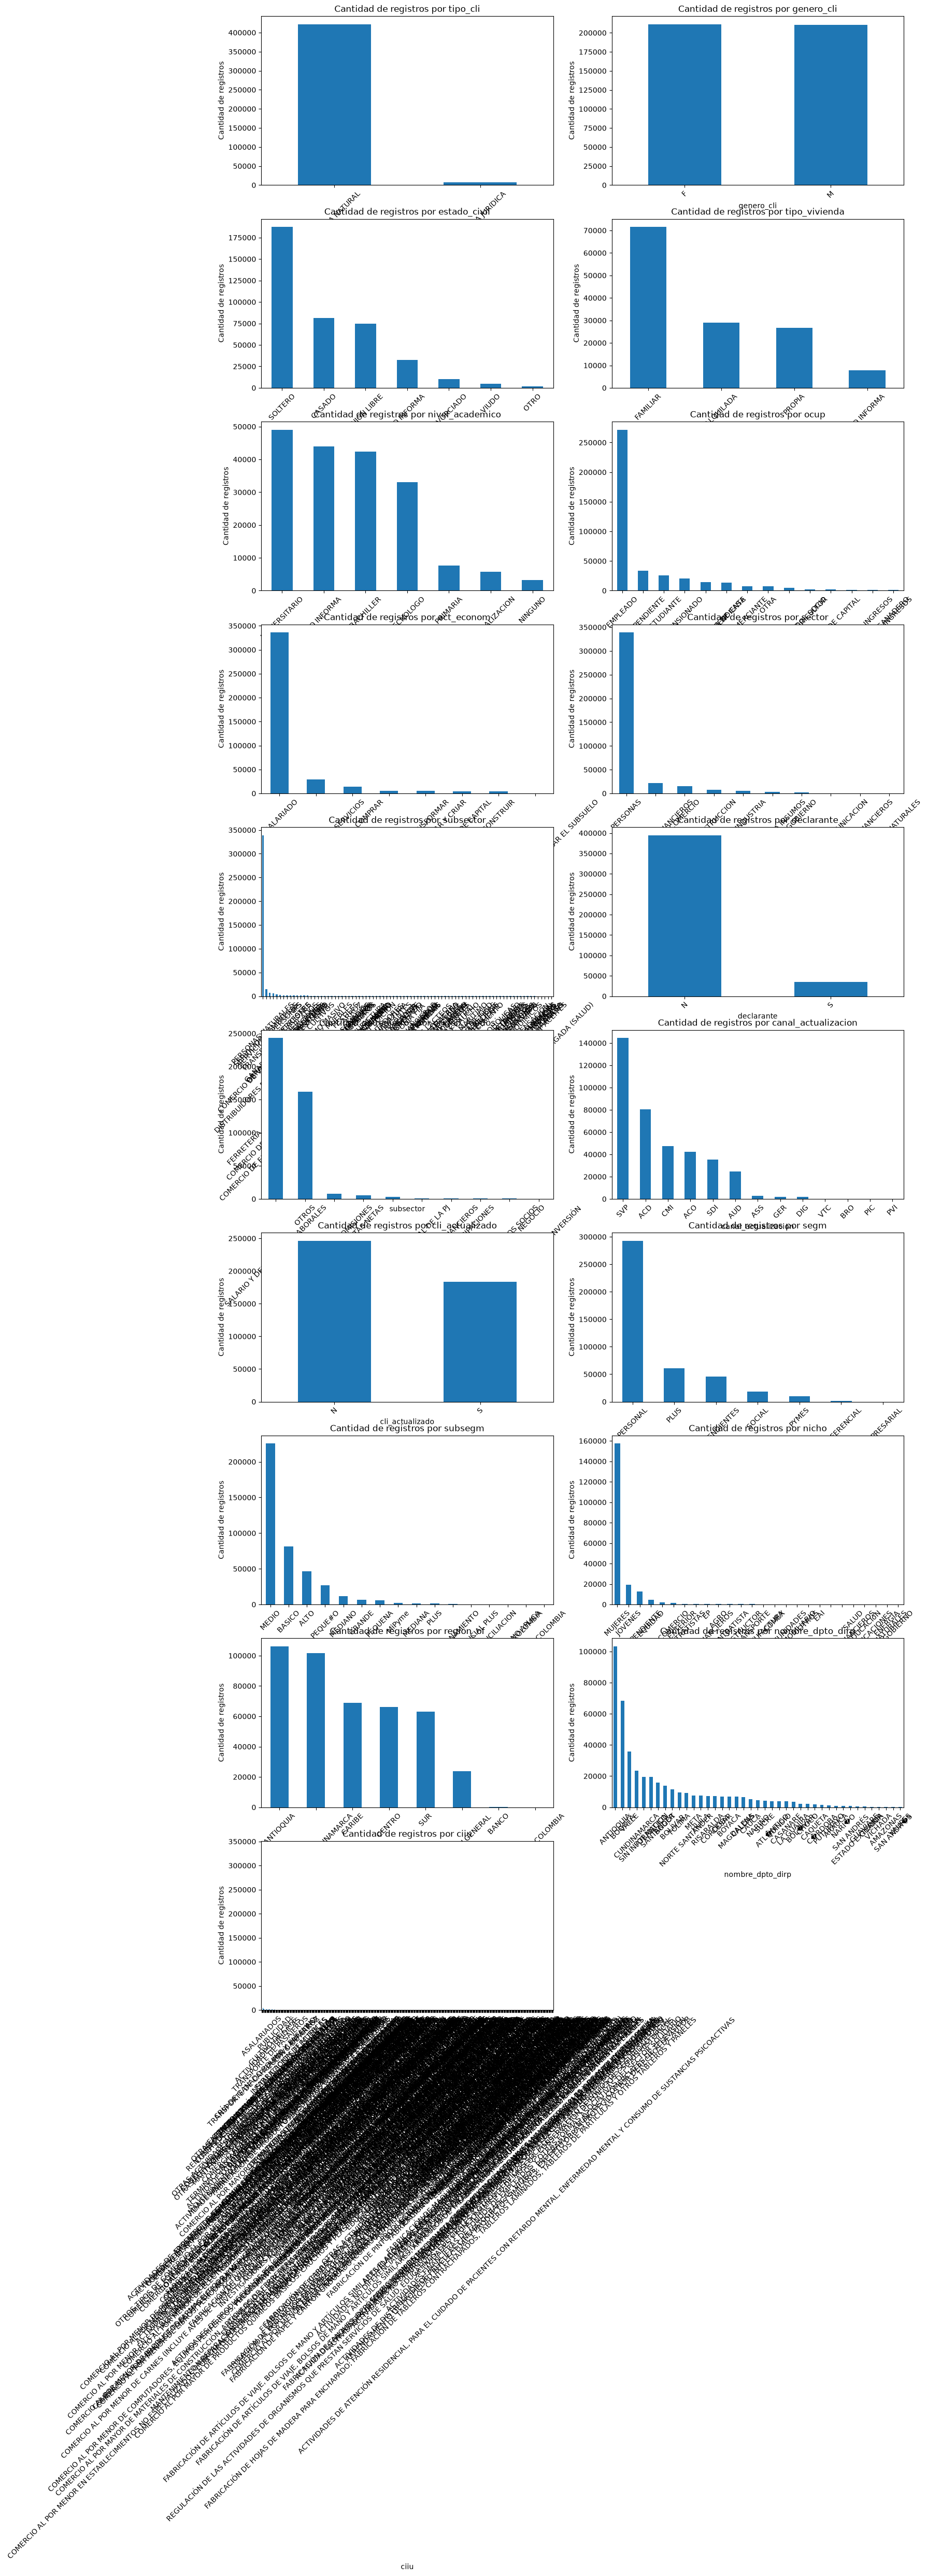

In [87]:
columnas_categoricas = ["tipo_cli", "genero_cli", "estado_civil", "tipo_vivienda", "nivel_academico", 
                        "ocup", "act_econom", "sector", "subsector", "declarante", "origen_fondos", 
                        "canal_actualizacion", "cli_actualizado", "segm", "subsegm", "nicho", "region_of", 
                        "nombre_dpto_dirp", "ciiu"]

import math

n_variables = len(columnas_categoricas)
n_cols = 2
n_rows = math.ceil(n_variables / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 5 * n_rows))
axes = axes.flatten()

for ax, columna in zip(axes, columnas_categoricas):
    conteo = master_customer_data[columna].value_counts().sort_values(ascending=False)
    conteo.plot(kind="bar", ax=ax)
    ax.set_title(f"Cantidad de registros por {columna}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Cantidad de registros")
    ax.tick_params(axis="x", rotation=45)

# Ocultar ejes sobrantes cuando las variables no llenan la grilla completa
for ax in axes[n_variables:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

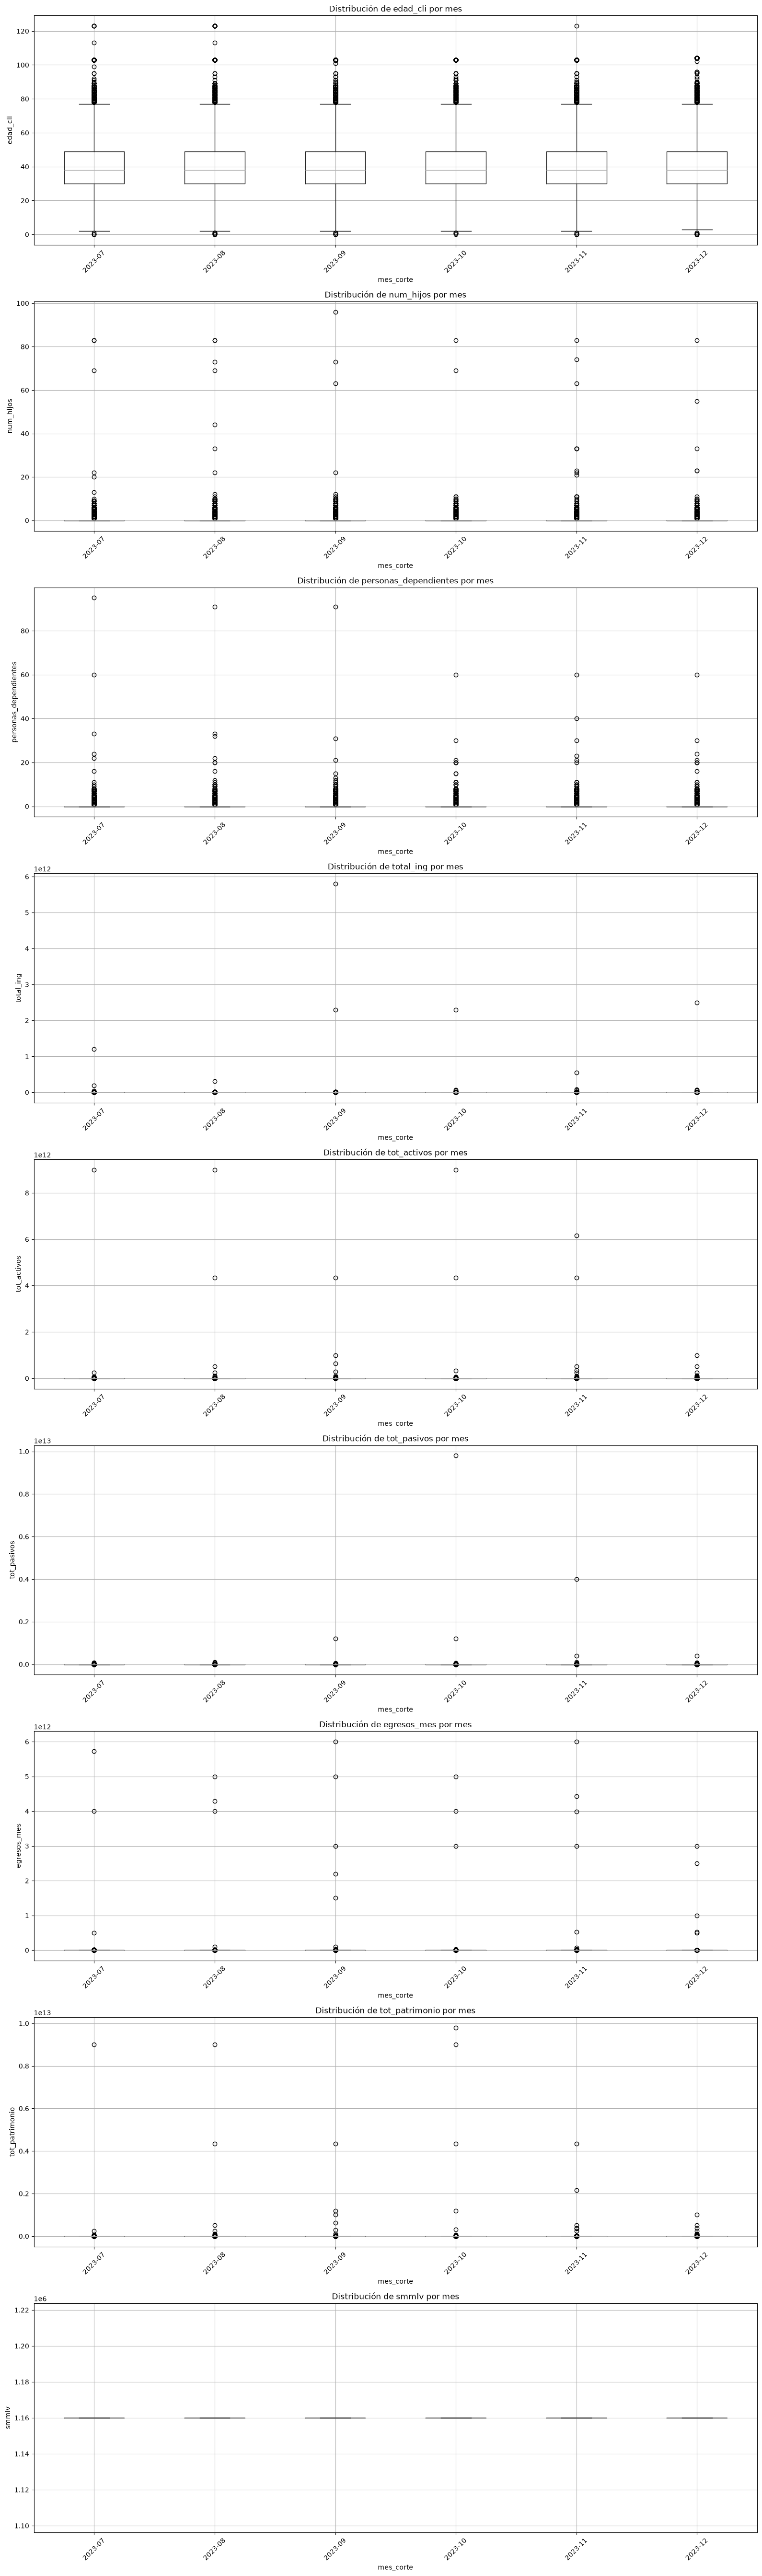

In [88]:
master_customer_data["mes_corte"] = pd.to_datetime(
    master_customer_data[["year", "month"]].assign(day=1)
).dt.to_period("M").astype(str)

columnas_numericas = ["edad_cli", "num_hijos", "personas_dependientes", "total_ing", "tot_activos", 
                      "tot_pasivos", "egresos_mes", "tot_patrimonio", "smmlv"]

n_variables = len(columnas_numericas)
fig, axes = plt.subplots(n_variables, 1, figsize=(16, 6 * n_variables))
axes = axes if n_variables > 1 else [axes]

for ax, columna in zip(axes, columnas_numericas):
    master_customer_data.boxplot(column=columna, by="mes_corte", ax=ax, rot=45)
    ax.set_title(f"Distribución de {columna} por mes")
    ax.set_xlabel("mes_corte")
    ax.set_ylabel(columna)

plt.suptitle("")
plt.tight_layout()
plt.show()

In [89]:
master_customer_data["mes_corte"] = pd.to_datetime(
    master_customer_data[["year", "month"]].assign(day=1)
).dt.to_period("M").astype(str)

columnas = columnas_numericas + columnas_categoricas
nulos_por_mes = (
    master_customer_data.groupby("mes_corte")[columnas]
    .apply(lambda grupo: grupo.isnull().sum())
)

nulos_por_mes

,edad_cli,num_hijos,personas_dependientes,total_ing,tot_activos,tot_pasivos,egresos_mes,tot_patrimonio,smmlv,tipo_cli,...,declarante,origen_fondos,canal_actualizacion,cli_actualizado,segm,subsegm,nicho,region_of,nombre_dpto_dirp,ciiu
mes_corte,,,,,,,,,,,,,,,,,,,,,
2023-07,1320,1320,1320,1,1,1,1,1,0,0,...,37,1331,8028,0,11,3398,37732,0,249,8538
2023-08,1326,1326,1327,0,0,0,0,0,0,0,...,43,1027,8091,0,9,3255,37867,0,223,6124
2023-09,1300,1300,1300,1,1,1,1,1,0,0,...,32,917,7908,0,6,3120,37968,0,206,4722
2023-10,1342,1342,1343,2,2,2,2,2,0,0,...,35,865,8417,0,4,3000,37887,0,179,4556
2023-11,1330,1330,1331,0,0,0,0,0,0,0,...,22,654,7962,0,0,2954,37835,0,211,4634
2023-12,1324,1324,1324,0,0,0,0,0,0,0,...,9,522,7642,0,1,2797,37973,0,202,4694


## Analisis probabilidad_oblig

In [90]:
probabilidad_oblig.keys()

Index(['nit_enmascarado', 'num_oblig_enmascarado', 'fecha_corte', 'lote',
       'prob_propension', 'prob_alrt_temprana', 'prob_auto_cura'],
      dtype='str')

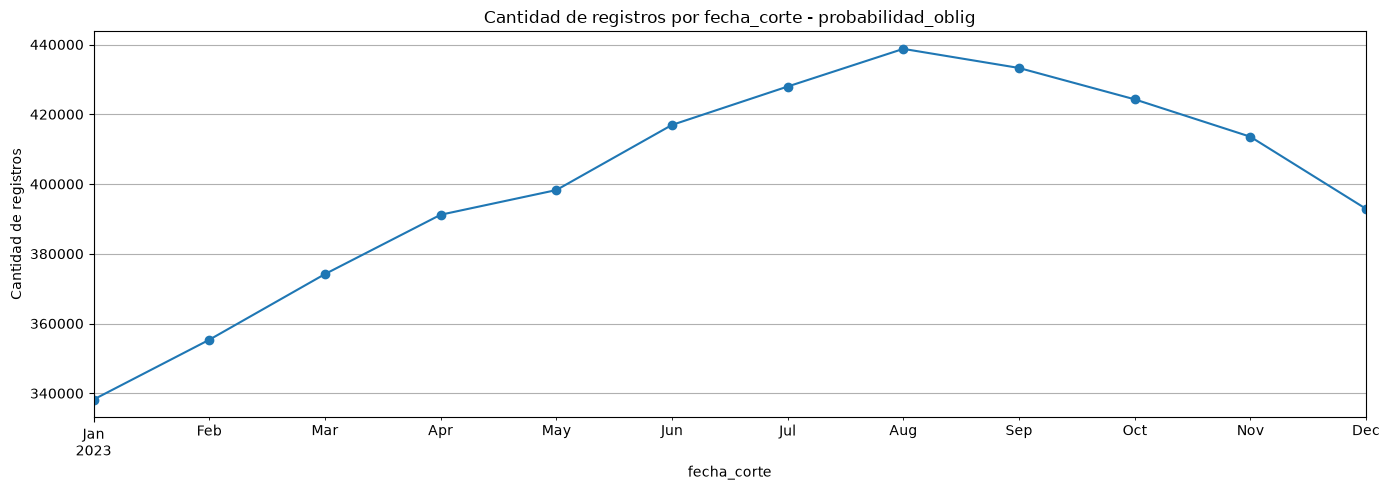

In [91]:
# Conteo de registros por fecha_corte
fecha_corte_counts = (
    probabilidad_oblig["fecha_corte"]
    .astype(str)
    .pipe(pd.to_datetime, format="%Y%m")
    .value_counts()
    .sort_index()   
)

plt.figure(figsize=(14, 5))
fecha_corte_counts.plot(kind="line", marker="o")
plt.title("Cantidad de registros por fecha_corte - probabilidad_oblig")
plt.xlabel("fecha_corte")
plt.ylabel("Cantidad de registros")
plt.grid(True)
plt.tight_layout()
plt.show()


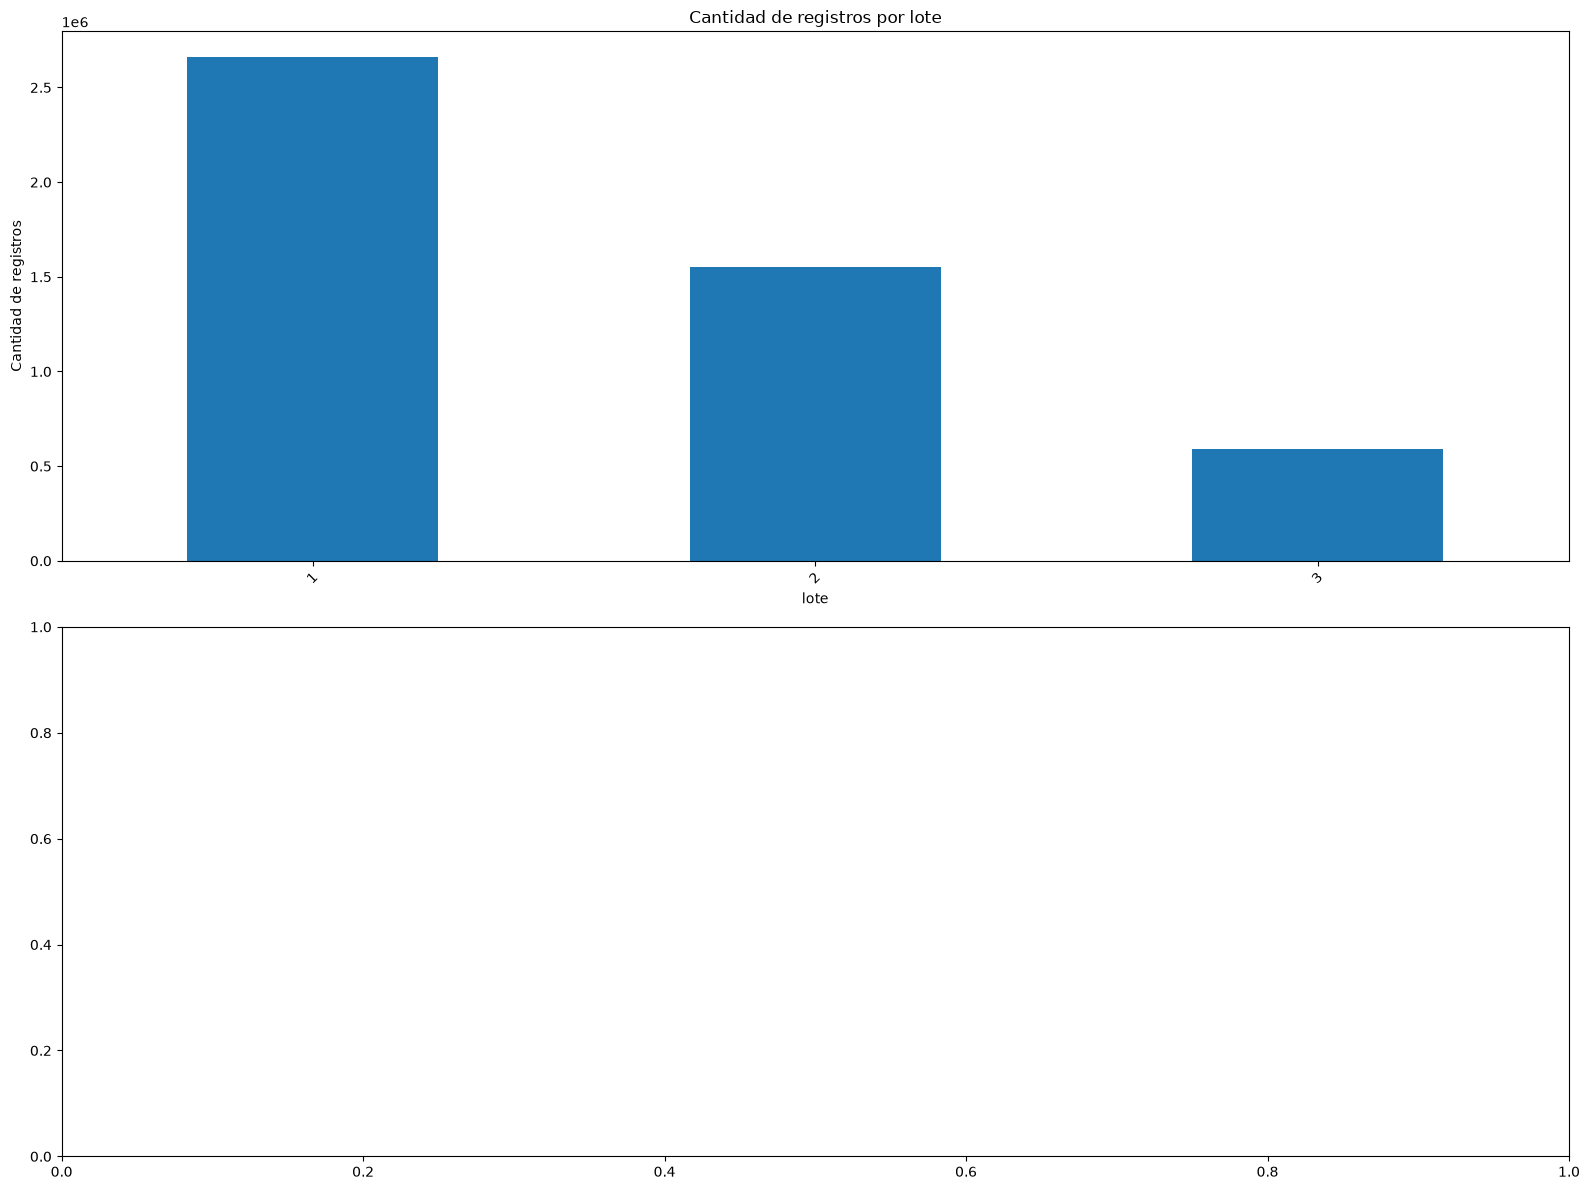

In [92]:
columnas_categoricas = ["lote"]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

for ax, columna in zip(axes.flatten(), columnas_categoricas):
    conteo = probabilidad_oblig[columna].value_counts().sort_values(ascending=False)
    conteo.plot(kind="bar", ax=ax)
    ax.set_title(f"Cantidad de registros por {columna}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Cantidad de registros")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

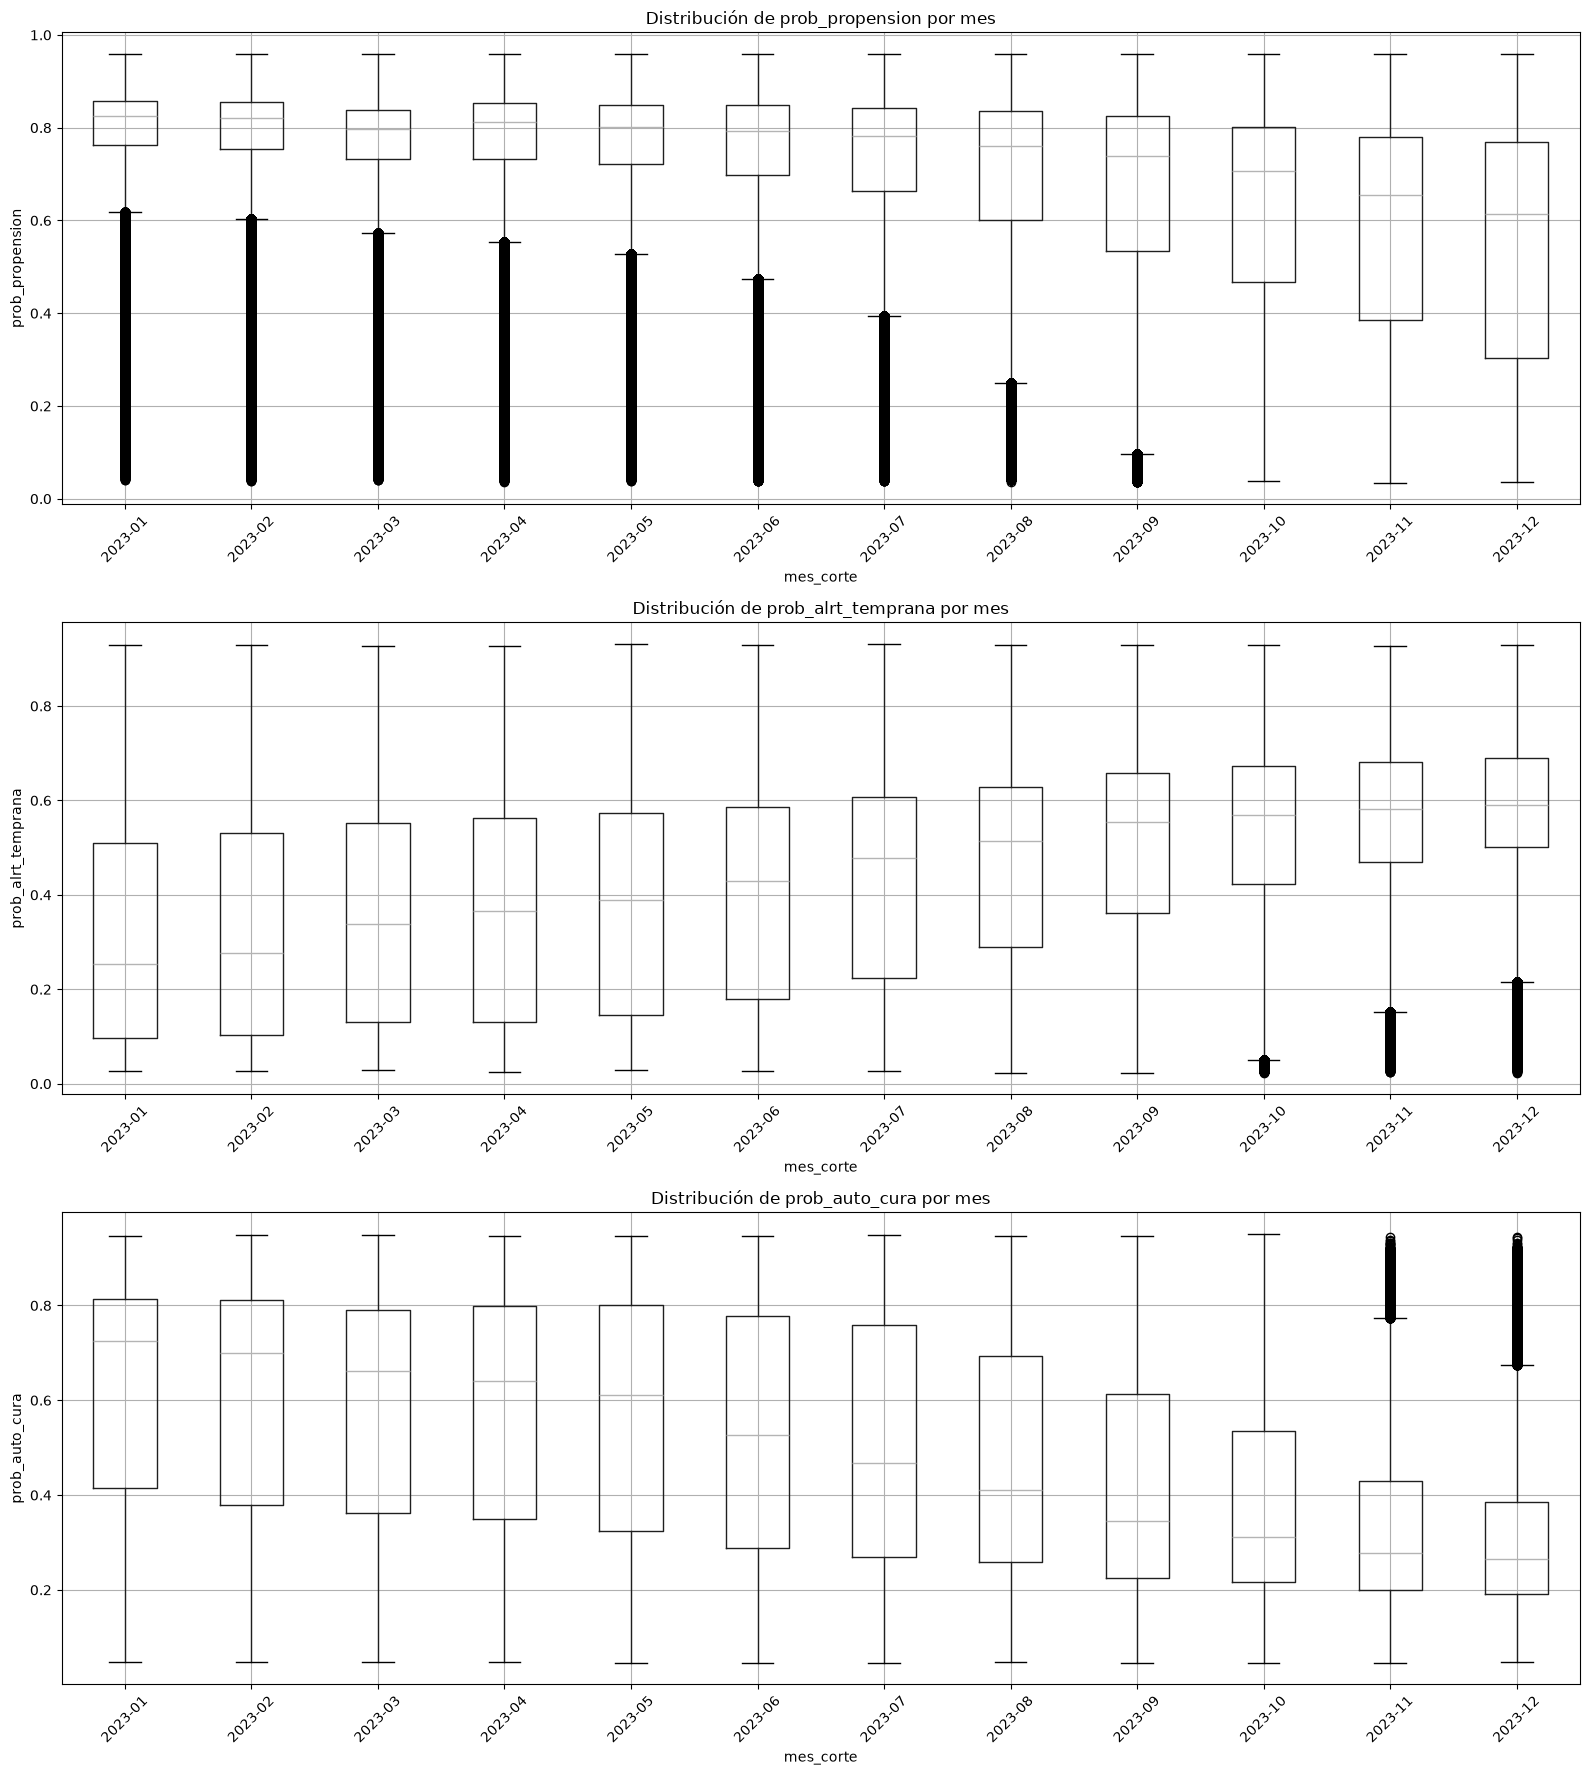

In [93]:
probabilidad_oblig["mes_corte"] = pd.to_datetime(
    probabilidad_oblig["fecha_corte"].astype(str), format="%Y%m"
).dt.to_period("M").astype(str)

columnas_numericas = ['prob_propension', 'prob_alrt_temprana', 'prob_auto_cura']

fig, axes = plt.subplots(len(columnas_numericas), 1, figsize=(16, 18))

for ax, columna in zip(axes, columnas_numericas):
    probabilidad_oblig.boxplot(column=columna, by="mes_corte", ax=ax, rot=45)
    ax.set_title(f"Distribución de {columna} por mes")
    ax.set_xlabel("mes_corte")
    ax.set_ylabel(columna)

plt.suptitle("")
plt.tight_layout()
plt.show()

In [94]:
columnas = columnas_numericas + columnas_categoricas
nulos_por_mes = (
    probabilidad_oblig.groupby("mes_corte")[columnas]
    .apply(lambda grupo: grupo.isnull().sum())
)

nulos_por_mes

,prob_propension,prob_alrt_temprana,prob_auto_cura,lote
mes_corte,,,,
2023-01,0,0,0,0
2023-02,0,0,0,0
2023-03,0,0,0,0
2023-04,0,7,7,0
2023-05,0,0,0,0
2023-06,0,0,0,0
2023-07,0,0,0,0
2023-08,0,0,0,0
2023-09,0,0,0,0


## Preparacion Dataset de entrenamiento

### Procesamiento Master_customer_data

In [95]:
# Para cada nit_enmascarado, cod_tipo_doc y mes (year, month), nos quedamos
# solo con el registro mas reciente segun ingestion_day
master_customer_data = (
    master_customer_data
    .sort_values("ingestion_day")
    .drop_duplicates(
        subset=["nit_enmascarado", "cod_tipo_doc", "year", "month"],
        keep="last"
    )
    .reset_index(drop=True)
)

master_customer_data.head()

,nit_enmascarado,cod_tipo_doc,tipo_cli,ctrl_terc,genero_cli,ano_nac_cli,edad_cli,estado_civil,tipo_vivienda,num_hijos,...,region_of,nombre_dpto_dirp,egresos_mes,tot_patrimonio,ciiu,smmlv,year,month,ingestion_day,mes_corte
0,630464,1,PERSONA NATURAL,CLIENTE,F,1997.0,26.0,SOLTERO,NaN,0.0,...,ANTIOQUIA,ANTIOQUIA,50000.0,1.320000e+07,ASALARIADOS,1160000.0,2023,11,30,2023-11
1,141769,1,PERSONA NATURAL,CLIENTE,F,1965.0,58.0,SOLTERO,PROPIA,1.0,...,BOGOTA Y CUNDINAMARCA,BOGOTÁ,600000.0,1.499000e+09,ASALARIADOS,1160000.0,2023,11,30,2023-11
2,552797,1,PERSONA NATURAL,CLIENTE,M,1994.0,29.0,SOLTERO,NaN,0.0,...,BOGOTA Y CUNDINAMARCA,TOLIMA,200000.0,5.000000e+06,RENTISTAS DE CAPITAL SÓLO PARA PERSONAS NATURALES,1160000.0,2023,9,30,2023-09
3,5788,1,PERSONA NATURAL,CLIENTE SOCIAL,M,1960.0,63.0,NaN,NaN,0.0,...,DIRECCIÓN GENERAL,SIN INFORMACION,0.0,0.000000e+00,ASALARIADOS,1160000.0,2023,11,30,2023-11
4,512257,1,PERSONA NATURAL,CLIENTE,F,1984.0,38.0,UNION LIBRE,PROPIA,0.0,...,CARIBE,MAGDALENA,250000.0,5.000000e+06,ASALARIADOS,1160000.0,2023,9,30,2023-09


### Preprocesamiento de master_customer_data para modelo de clasificacion

Con `master_customer_data` ya deduplicado (un registro por `nit_enmascarado`, `cod_tipo_doc`, `year`, `month`),
se aplica el siguiente procesamiento para dejarlo listo como insumo de un modelo de clasificacion:

- **Antiguedad del cliente**: se deriva `antiguedad_meses` a partir de `f_vinc` (fecha de vinculacion) y el
  mes de corte (`year`, `month`), en lugar de usar la fecha cruda.
- **Imputacion de nulos**: numericas con la mediana, categoricas con la etiqueta `SIN_INFORMACION`.
- **Reduccion de cardinalidad**: las categoricas con mas de 15 categorias se agrupan dejando las mas
  frecuentes y el resto como `OTRO`, para evitar explosion de columnas al codificar.
- **Transformacion de variables monetarias** (`total_ing`, `tot_activos`, `tot_pasivos`, `egresos_mes`,
  `tot_patrimonio`): `log1p`, dado que se observo alta asimetria en los boxplots por mes.
- **Codificacion one-hot** de las variables categoricas ya con cardinalidad reducida, incluyendo
  `estado_civil`, `tipo_vivienda` y `ctrl_terc` como variables relevantes para el modelo.
- **Eliminacion de columnas de control/fecha** (`f_vinc`, `f_ult_mantenimiento`, `ingestion_day`,
  `mes_corte`) que no aportan al modelo, manteniendo `nit_enmascarado`, `year` y `month` como llave.

In [96]:
import numpy as np

master_customer_data_ml = master_customer_data.copy()

# Antiguedad del cliente en meses, a partir de f_vinc y el mes de corte (year, month)
fecha_corte_dt = pd.to_datetime(master_customer_data_ml[["year", "month"]].assign(day=1))
f_vinc_dt = pd.to_datetime(master_customer_data_ml["f_vinc"], errors="coerce")
master_customer_data_ml["antiguedad_meses"] = (
    (fecha_corte_dt.dt.year - f_vinc_dt.dt.year) * 12
    + (fecha_corte_dt.dt.month - f_vinc_dt.dt.month)
)

columnas_numericas_ml = [
    "edad_cli", "num_hijos", "personas_dependientes", "total_ing", "tot_activos", "tot_pasivos",
    "egresos_mes", "tot_patrimonio", "smmlv", "antiguedad_meses"
]

columnas_categoricas_ml = [
    "cod_tipo_doc", "tipo_cli", "ctrl_terc", "genero_cli", "estado_civil", "tipo_vivienda", "nivel_academico",
    "ocup", "act_econom", "sector", "subsector", "declarante", "origen_fondos",
    "canal_actualizacion", "cli_actualizado", "segm", "subsegm", "nicho", "region_of",
    "nombre_dpto_dirp", "ciiu"
]

# Imputacion: numericas con la mediana, categoricas con "SIN_INFORMACION"
for col in columnas_numericas_ml:
    master_customer_data_ml[col] = master_customer_data_ml[col].fillna(master_customer_data_ml[col].median())

for col in columnas_categoricas_ml:
    master_customer_data_ml[col] = master_customer_data_ml[col].fillna("SIN_INFORMACION").astype(str)


def agrupar_categorias_frecuentes(serie, top_n=15):
    # Evita explosion de columnas al codificar variables con muchas categorias
    top_categorias = serie.value_counts().nlargest(top_n).index
    return serie.where(serie.isin(top_categorias), "OTRO")


for col in columnas_categoricas_ml:
    if master_customer_data_ml[col].nunique() > 15:
        master_customer_data_ml[col] = agrupar_categorias_frecuentes(master_customer_data_ml[col])

# Razones financieras calculadas antes de transformar/eliminar las columnas monetarias crudas
master_customer_data_ml["pasivo_sobre_patrimonio"] = (
    master_customer_data_ml["tot_pasivos"] / master_customer_data_ml["tot_patrimonio"]
).replace([np.inf, -np.inf], np.nan)
master_customer_data_ml["pasivo_sobre_activo"] = (
    master_customer_data_ml["tot_pasivos"] / master_customer_data_ml["tot_activos"]
).replace([np.inf, -np.inf], np.nan)
master_customer_data_ml["egreso_sobre_ingreso"] = (
    master_customer_data_ml["egresos_mes"] / master_customer_data_ml["total_ing"]
).replace([np.inf, -np.inf], np.nan)

# Se conserva el ingreso crudo (sin log1p) para calcular carga_cuota_ingreso a nivel obligacion mas adelante
master_customer_data_ml["total_ing_raw"] = master_customer_data_ml["total_ing"]

# Log1p para variables monetarias con alta asimetria
columnas_monetarias = ["total_ing", "tot_activos", "tot_pasivos", "egresos_mes", "tot_patrimonio"]
for col in columnas_monetarias:
    master_customer_data_ml[f"{col}_log"] = np.log1p(master_customer_data_ml[col].clip(lower=0))

master_customer_data_ml = master_customer_data_ml.drop(columns=columnas_monetarias)

# One-hot encoding de las categoricas ya con cardinalidad reducida
master_customer_data_ml = pd.get_dummies(
    master_customer_data_ml, columns=columnas_categoricas_ml, drop_first=True
)

# Columnas de control/fecha que no aportan al modelo (se conserva la llave nit_enmascarado, year, month)
master_customer_data_ml = master_customer_data_ml.drop(
    columns=["f_vinc", "f_ult_mantenimiento", "ingestion_day", "mes_corte"]
)

master_customer_data_ml.head()

,nit_enmascarado,ano_nac_cli,edad_cli,num_hijos,personas_dependientes,smmlv,year,month,antiguedad_meses,pasivo_sobre_patrimonio,...,ciiu_CONSTRUCCIÓN DE OTRAS OBRAS DE INGENIERÍA CIVIL,ciiu_CRÍA DE GANADO BOVINO Y BUFALINO,ciiu_OTRAS ACTIVIDADES DE SERVICIO DE APOYO A LAS EMPRESAS N.C.P.,ciiu_OTRAS ACTIVIDADES DE SERVICIOS PERSONALES N.C.P.,"ciiu_OTRAS ACTIVIDADES PROFESIONALES, CIENTÍFICAS Y TÉCNICAS N.C.P.",ciiu_OTRO,ciiu_PELUQUERÍA Y OTROS TRATAMIENTOS DE BELLEZA,ciiu_RENTISTAS DE CAPITAL SÓLO PARA PERSONAS NATURALES,ciiu_SIN_INFORMACION,ciiu_TRANSPORTE DE CARGA POR CARRETERA
0,630464,1997.0,26.0,0.0,0.0,1160000.0,2023,11,646,0.000000,...,False,False,False,False,False,False,False,False,False,False
1,141769,1965.0,58.0,1.0,1.0,1160000.0,2023,11,646,0.000667,...,False,False,False,False,False,False,False,False,False,False
2,552797,1994.0,29.0,0.0,0.0,1160000.0,2023,9,644,0.000000,...,False,False,False,False,False,False,False,True,False,False
3,5788,1960.0,63.0,0.0,0.0,1160000.0,2023,11,646,NaN,...,False,False,False,False,False,False,False,False,False,False
4,512257,1984.0,38.0,0.0,0.0,1160000.0,2023,9,644,0.000000,...,False,False,False,False,False,False,False,False,False,False


In [97]:
maestra_cuota.keys()

Index(['nit_enmascarado', 'num_oblig_enmascarado', 'fecha_corte', 'producto',
       'aplicativo', 'segmento', 'valor_cuota_mes', 'pago_total',
       'fecha_pago_minima', 'fecha_pago_maxima', 'porc_pago', 'marca_pago',
       'ajustes_banco', 'mes_corte'],
      dtype='str')

In [98]:
# Para cada nit_enmascarado, num_oblig_enmascarado y mes (fecha_corte), nos quedamos
# solo con el registro mas reciente
maestra_cuota = (
    maestra_cuota
    .sort_values("fecha_corte")
    .drop_duplicates(
        subset=["nit_enmascarado", "num_oblig_enmascarado", "fecha_corte"],
        keep="last"
    )
    .reset_index(drop=True)
)

maestra_cuota

,nit_enmascarado,num_oblig_enmascarado,fecha_corte,producto,aplicativo,segmento,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,marca_pago,ajustes_banco,mes_corte
0,629776,796480,20230131,TARJETA DE CREDITO,V,PERSONAL,183797.0,800000.0,20230116.0,20230116.0,435.0,PAGO_MAS,NO,2023-01
1,127027,175450,20230131,LIBRE INVERSION,L,SOCIAL,221544.0,6464.0,20230103.0,20230103.0,3.0,IGUAL,NO,2023-01
2,79660,177950,20230131,LIBRE INVERSION,L,SOCIAL,191362.0,574086.0,20221209.0,20221209.0,300.0,PAGO_MAS,NO,2023-01
3,547681,781131,20230131,TARJETA DE CREDITO,V,PERSONAL,0.0,0.0,NaN,NaN,NaN,IGUAL,NO,2023-01
4,129704,765850,20230131,TARJETA DE CREDITO,V,MICROPYME,1146702.0,5733508.0,20230105.0,20230105.0,500.0,PAGO_MAS,NO,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4855014,219557,811886,20231231,TARJETA DE CREDITO,V,MICROPYME,415697.0,0.0,NaN,NaN,0.0,PAGO_MENOS,NO,2023-12
4855015,570332,429939,20231231,LIBRE INVERSION,L,PERSONAL PLUS,544546.0,0.0,NaN,NaN,0.0,FACTURACION_MES_SGTE,NO,2023-12
4855016,471691,340762,20231231,LIBRE INVERSION,L,PERSONAL,1259783.0,46491843.0,20231112.0,20231216.0,3690.0,FACTURACION_MES_SGTE,NO,2023-12
4855017,283507,540928,20231231,ROTATIVOS,L,PERSONAL PLUS,151426.0,0.0,NaN,NaN,0.0,NO_PAGO,NO,2023-12


### Resumen de maestra_cuota a nivel nit_enmascarado, num_oblig_enmascarado, year, month

`maestra_cuota` ya deduplicada queda con un unico registro por `nit_enmascarado`, `num_oblig_enmascarado`,
`year` y `month` (una fila por obligacion y mes), por lo que ya no es necesario agregar entre obligaciones.
La estrategia es enriquecer cada registro manteniendo esa granularidad:

- **Flag de ajuste del banco**: `1` si `ajustes_banco = SI` en ese registro.
- **Imputacion y codificacion one-hot** de `marca_pago`, `producto`, `segmento` y `aplicativo`, para que
  el modelo interprete el comportamiento de pago, el tipo de obligacion, el segmento y el aplicativo de
  cada registro.
- **Eliminacion de columnas redundantes** (`fecha_corte`, `mes_corte`, `ajustes_banco`) que ya no aportan
  tras el encoding, manteniendo `nit_enmascarado`, `num_oblig_enmascarado`, `year` y `month` como llave.

In [99]:
# year y month a partir de fecha_corte, para igualar la granularidad de master_customer_data
maestra_cuota["year"] = maestra_cuota["fecha_corte"].astype(str).str[:4].astype(int)
maestra_cuota["month"] = maestra_cuota["fecha_corte"].astype(str).str[4:6].astype(int)

llave = ["nit_enmascarado", "num_oblig_enmascarado", "year", "month"]

# Tras la deduplicacion, nit_enmascarado, num_oblig_enmascarado, year y month ya identifican un registro unico
assert not maestra_cuota.duplicated(subset=llave).any()

maestra_cuota_resumen = maestra_cuota.copy()

# Flag de ajuste del banco en el registro
maestra_cuota_resumen["ajuste_banco_flag"] = (maestra_cuota_resumen["ajustes_banco"] == "SI").astype(int)

# Imputacion de categoricas antes de codificar
columnas_categoricas_cuota = ["marca_pago", "producto", "segmento", "aplicativo"]
for col in columnas_categoricas_cuota:
    maestra_cuota_resumen[col] = maestra_cuota_resumen[col].fillna("SIN_INFORMACION").astype(str)

# One-hot encoding de las categoricas, para que el modelo interprete el comportamiento de pago,
# el tipo de obligacion, el segmento y el aplicativo de cada registro
maestra_cuota_resumen = pd.get_dummies(maestra_cuota_resumen, columns=columnas_categoricas_cuota)

# Columnas que ya no aportan tras el encoding (se conserva la llave nit_enmascarado, num_oblig_enmascarado, year, month)
maestra_cuota_resumen = maestra_cuota_resumen.drop(columns=["fecha_corte", "mes_corte", "ajustes_banco"])

maestra_cuota_resumen.head()

,nit_enmascarado,num_oblig_enmascarado,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,year,month,ajuste_banco_flag,...,segmento_PREFERENCIAL,segmento_PYMES,segmento_SOCIAL,aplicativo_3,aplicativo_4,aplicativo_D,aplicativo_K,aplicativo_L,aplicativo_M,aplicativo_V
0,629776,796480,183797.0,800000.0,20230116.0,20230116.0,435.0,2023,1,0,...,False,False,False,False,False,False,False,False,False,True
1,127027,175450,221544.0,6464.0,20230103.0,20230103.0,3.0,2023,1,0,...,False,False,True,False,False,False,False,True,False,False
2,79660,177950,191362.0,574086.0,20221209.0,20221209.0,300.0,2023,1,0,...,False,False,True,False,False,False,False,True,False,False
3,547681,781131,0.0,0.0,NaN,NaN,NaN,2023,1,0,...,False,False,False,False,False,False,False,False,False,True
4,129704,765850,1146702.0,5733508.0,20230105.0,20230105.0,500.0,2023,1,0,...,False,False,False,False,False,False,False,False,False,True


### Variables adicionales: frecuencia del cliente, obligaciones simultaneas y variacion de deuda

Sobre `maestra_cuota_resumen` (a nivel `nit_enmascarado`, `num_oblig_enmascarado`, `year`, `month`) se
calculan tres variables nuevas:

- **`conteo_nit_3m`**: cuantas veces aparece el mismo `nit_enmascarado` (en cualquier obligacion) en los
  3 meses anteriores al mes del registro. Sin historial en esos meses, se rellena con `0`.
- **`n_obligaciones_mes`**: cuantas obligaciones distintas (`num_oblig_enmascarado`) tiene el
  `nit_enmascarado` en ese mismo mes.
- **`prop_deuda_actual_vs_previas`**: proporcion entre la deuda del mes (`valor_cuota_mes`) y el promedio
  de la deuda de los meses anteriores, para cada `nit_enmascarado`/`num_oblig_enmascarado`. Sin meses
  anteriores (primer registro de la obligacion) o con deuda previa promedio de `0`, se asume una razon
  estable (`1`).

In [100]:
maestra_cuota_resumen["periodo"] = maestra_cuota_resumen["year"] * 12 + maestra_cuota_resumen["month"]

# Registros (obligacion-mes) por nit_enmascarado y periodo, para contar apariciones en meses anteriores
registros_por_nit_periodo = (
    maestra_cuota.assign(periodo=maestra_cuota["year"] * 12 + maestra_cuota["month"])
    .groupby(["nit_enmascarado", "periodo"])
    .size()
    .rename("registros_mes")
    .reset_index()
)

conteo_nit_3m = maestra_cuota_resumen[["nit_enmascarado", "periodo"]].drop_duplicates().copy()
conteo_nit_3m["conteo_nit_3m"] = 0
for delta in (1, 2, 3):
    # Desplaza el periodo de origen delta meses hacia adelante para alinearlo con el periodo objetivo
    lookup = registros_por_nit_periodo.copy()
    lookup["periodo"] = lookup["periodo"] + delta
    conteo_delta = conteo_nit_3m[["nit_enmascarado", "periodo"]].merge(
        lookup, on=["nit_enmascarado", "periodo"], how="left"
    )["registros_mes"]
    conteo_nit_3m["conteo_nit_3m"] += conteo_delta.fillna(0).astype(int)

maestra_cuota_resumen = maestra_cuota_resumen.merge(conteo_nit_3m, on=["nit_enmascarado", "periodo"], how="left")

# Obligaciones distintas del mismo nit_enmascarado en el mismo mes
maestra_cuota_resumen["n_obligaciones_mes"] = maestra_cuota_resumen.groupby(
    ["nit_enmascarado", "periodo"]
)["num_oblig_enmascarado"].transform("nunique")

# Cantidad total de obligaciones distintas que ha tenido el nit_enmascarado (historico, todos los meses)
cantidad_obligaciones_por_nit = (
    maestra_cuota.groupby("nit_enmascarado")["num_oblig_enmascarado"]
    .nunique()
    .rename("cantidad_obligaciones_por_nit")
    .reset_index()
)
maestra_cuota_resumen = maestra_cuota_resumen.merge(
    cantidad_obligaciones_por_nit, on="nit_enmascarado", how="left"
)

# Suma de la cuota exigida entre todas las obligaciones del nit_enmascarado en el mismo mes,
# insumo para calcular mas adelante carga_cuota_ingreso (cuota total del cliente / su ingreso)
cuota_total_nit_mes = (
    maestra_cuota_resumen.groupby(["nit_enmascarado", "periodo"])["valor_cuota_mes"]
    .sum()
    .rename("cuota_total_nit_mes")
    .reset_index()
)
maestra_cuota_resumen = maestra_cuota_resumen.merge(
    cuota_total_nit_mes, on=["nit_enmascarado", "periodo"], how="left"
)

# Promedio de la deuda (valor_cuota_mes) de los meses anteriores, por nit_enmascarado y obligacion
maestra_cuota_resumen = maestra_cuota_resumen.sort_values(
    ["nit_enmascarado", "num_oblig_enmascarado", "periodo"]
)
deuda_previa_promedio = (
    maestra_cuota_resumen
    .groupby(["nit_enmascarado", "num_oblig_enmascarado"])["valor_cuota_mes"]
    .apply(lambda serie: serie.shift(1).expanding().mean())
    .reset_index(level=[0, 1], drop=True)
)
maestra_cuota_resumen["prop_deuda_actual_vs_previas"] = (
    maestra_cuota_resumen["valor_cuota_mes"] / deuda_previa_promedio
)
# Sin meses anteriores o con deuda previa promedio 0 se asume una razon estable
maestra_cuota_resumen["prop_deuda_actual_vs_previas"] = (
    maestra_cuota_resumen["prop_deuda_actual_vs_previas"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1)
)

maestra_cuota_resumen = maestra_cuota_resumen.drop(columns=["periodo"])

maestra_cuota_resumen.head()

,nit_enmascarado,num_oblig_enmascarado,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,year,month,ajuste_banco_flag,...,aplicativo_D,aplicativo_K,aplicativo_L,aplicativo_M,aplicativo_V,conteo_nit_3m,n_obligaciones_mes,cantidad_obligaciones_por_nit,cuota_total_nit_mes,prop_deuda_actual_vs_previas
222748,1,104488,102247.0,206000.0,20230104.0,20230104.0,201.0,2023,1,0,...,False,False,True,False,False,0.0,1,1,102247.0,1.000000
346199,1,104488,102247.0,206000.0,20230201.0,20230201.0,201.0,2023,2,0,...,False,False,True,False,False,1.0,1,1,102247.0,1.000000
877488,1,104488,102247.0,206000.0,20230301.0,20230301.0,201.0,2023,3,0,...,False,False,True,False,False,3.0,1,1,102247.0,1.000000
1156489,1,104488,102247.0,23514.0,20230404.0,20230404.0,23.0,2023,4,0,...,False,False,True,False,False,3.0,1,1,102247.0,1.000000
1659549,1,104488,122102.0,142338.0,20230502.0,20230502.0,117.0,2023,5,0,...,False,False,True,False,False,6.0,1,1,122102.0,1.194187


### Variables adicionales: relacion pago vs. cuota exigida

Sobre `valor_cuota_mes` (cuota exigida) y `pago_total` (pago realizado) se calculan:

- **`ratio_pago_cuota`**: `pago_total / valor_cuota_mes`.
- **`deficit_pago`**: `valor_cuota_mes - pago_total` (positivo si falto pago, negativo si hubo sobrepago).
- **`deficit_rel`**: `deficit_pago` como proporcion de la cuota exigida.
- **`log_deficit`**: `log1p` de la parte positiva de `deficit_pago` (un deficit negativo es superavit de pago).
- **Banderas**: `no_pago_flag` (no hubo pago), `pago_cubre_cuota` (el pago alcanzo o supero la cuota),
  `sobrepago_flag` (el pago supero la cuota) y `porc_pago_out_flag` (`porc_pago` por encima de 100%, un
  valor absurdo).

In [101]:
# Relacion entre el pago realizado y la cuota exigida
maestra_cuota_resumen["ratio_pago_cuota"] = (
    maestra_cuota_resumen["pago_total"] / maestra_cuota_resumen["valor_cuota_mes"]
).replace([np.inf, -np.inf], np.nan)

maestra_cuota_resumen["deficit_pago"] = (
    maestra_cuota_resumen["valor_cuota_mes"] - maestra_cuota_resumen["pago_total"]
)
maestra_cuota_resumen["deficit_rel"] = (
    maestra_cuota_resumen["deficit_pago"] / maestra_cuota_resumen["valor_cuota_mes"]
).replace([np.inf, -np.inf], np.nan)

# log1p sobre la parte positiva del deficit; un deficit negativo es superavit de pago
maestra_cuota_resumen["log_deficit"] = np.log1p(maestra_cuota_resumen["deficit_pago"].clip(lower=0))

# Banderas de comportamiento de pago
maestra_cuota_resumen["no_pago_flag"] = (maestra_cuota_resumen["pago_total"] <= 0).astype(int)
maestra_cuota_resumen["pago_cubre_cuota"] = (
    maestra_cuota_resumen["pago_total"] >= maestra_cuota_resumen["valor_cuota_mes"]
).astype(int)
maestra_cuota_resumen["sobrepago_flag"] = (
    maestra_cuota_resumen["pago_total"] > maestra_cuota_resumen["valor_cuota_mes"]
).astype(int)
# porc_pago absurdo: por encima del 100% de la cuota exigida
maestra_cuota_resumen["porc_pago_out_flag"] = (maestra_cuota_resumen["porc_pago"] > 100).astype(int)

# Cuota promedio por obligacion del nit_enmascarado en el mes (cuota de esta obligacion entre el total
# de obligaciones que tiene el nit ese mismo mes)
maestra_cuota_resumen["cuota_por_obligacion"] = (
    maestra_cuota_resumen["valor_cuota_mes"] / maestra_cuota_resumen["n_obligaciones_mes"]
).replace([np.inf, -np.inf], np.nan)

maestra_cuota_resumen.head()

,nit_enmascarado,num_oblig_enmascarado,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,year,month,ajuste_banco_flag,...,prop_deuda_actual_vs_previas,ratio_pago_cuota,deficit_pago,deficit_rel,log_deficit,no_pago_flag,pago_cubre_cuota,sobrepago_flag,porc_pago_out_flag,cuota_por_obligacion
222748,1,104488,102247.0,206000.0,20230104.0,20230104.0,201.0,2023,1,0,...,1.000000,2.014729,-103753.0,-1.014729,0.00000,0,1,1,1,102247.0
346199,1,104488,102247.0,206000.0,20230201.0,20230201.0,201.0,2023,2,0,...,1.000000,2.014729,-103753.0,-1.014729,0.00000,0,1,1,1,102247.0
877488,1,104488,102247.0,206000.0,20230301.0,20230301.0,201.0,2023,3,0,...,1.000000,2.014729,-103753.0,-1.014729,0.00000,0,1,1,1,102247.0
1156489,1,104488,102247.0,23514.0,20230404.0,20230404.0,23.0,2023,4,0,...,1.000000,0.229973,78733.0,0.770027,11.27383,0,0,0,0,102247.0
1659549,1,104488,122102.0,142338.0,20230502.0,20230502.0,117.0,2023,5,0,...,1.194187,1.165730,-20236.0,-0.165730,0.00000,0,1,1,1,122102.0


### Variables autoregresivas de corto plazo (rezagos, cambios y ventana movil)

Para las variables que cambian mes a mes (`pago_total`, `valor_cuota_mes`, `porc_pago`, `prob_propension_mean`,
`prob_alrt_temprana_mean`, `prob_auto_cura_mean`, `hist_var_rpta_alt`, `marca_pago_*`,
`prop_deuda_actual_vs_previas`, `n_obligaciones_mes`) se calculan, por `nit_enmascarado`
(y `num_oblig_enmascarado` cuando la variable es a nivel obligacion):

- **Rezagos**: `_lag1` (mes anterior), `_lag2` (dos meses atras).
- **Cambios**: `_delta1` (vs. mes anterior), `_delta2` (cambio del mes anterior vs. el previo a ese) y
  `_accel` (aceleracion: cambio del cambio).
- **Ventana `[t-2, t]`**: `_mean3` (nivel promedio) y `_std3` (volatilidad).

Ademas se derivan `meses_consecutivos_no_pago`, `deterioro_pago` (pago menor al del mes anterior) y, mas
adelante, `riesgo_creciente` (alerta temprana en aumento).

In [102]:
def agregar_autoregresivas(df, columnas, group_cols, periodo_col="periodo"):
    # Rezagos (_lag1/_lag2), cambios (_delta1/_delta2/_accel) y ventana movil (_mean3/_std3),
    # calculados dentro de cada grupo y ordenados por periodo
    df = df.sort_values(group_cols + [periodo_col])
    agrupado = df.groupby(group_cols)
    for col in columnas:
        lag1 = agrupado[col].shift(1)
        lag2 = agrupado[col].shift(2)
        df[f"{col}_lag1"] = lag1
        df[f"{col}_lag2"] = lag2
        df[f"{col}_delta1"] = df[col] - lag1
        df[f"{col}_delta2"] = lag1 - lag2
        df[f"{col}_accel"] = df[f"{col}_delta1"] - df[f"{col}_delta2"]
        df[f"{col}_mean3"] = agrupado[col].transform(lambda serie: serie.rolling(3, min_periods=1).mean())
        df[f"{col}_std3"] = agrupado[col].transform(lambda serie: serie.rolling(3, min_periods=1).std())
    return df


maestra_cuota_resumen["periodo"] = maestra_cuota_resumen["year"] * 12 + maestra_cuota_resumen["month"]

columnas_marca_pago = [c for c in maestra_cuota_resumen.columns if c.startswith("marca_pago_")]
columnas_autoregresivas_oblig = [
    "pago_total", "valor_cuota_mes", "porc_pago", "prop_deuda_actual_vs_previas"
] + columnas_marca_pago

maestra_cuota_resumen = agregar_autoregresivas(
    maestra_cuota_resumen,
    columnas_autoregresivas_oblig,
    group_cols=["nit_enmascarado", "num_oblig_enmascarado"],
)

# n_obligaciones_mes es igual para todas las obligaciones del mismo nit_enmascarado en el mismo mes;
# su historial se calcula a nivel nit_enmascarado-mes (deduplicado) para no romper el orden temporal
n_oblig_mes_nit = maestra_cuota_resumen[
    ["nit_enmascarado", "periodo", "n_obligaciones_mes"]
].drop_duplicates(subset=["nit_enmascarado", "periodo"])
n_oblig_mes_nit = agregar_autoregresivas(
    n_oblig_mes_nit, ["n_obligaciones_mes"], group_cols=["nit_enmascarado"]
)
columnas_n_oblig_hist = [c for c in n_oblig_mes_nit.columns if c.startswith("n_obligaciones_mes_")]
maestra_cuota_resumen = maestra_cuota_resumen.merge(
    n_oblig_mes_nit[["nit_enmascarado", "periodo"] + columnas_n_oblig_hist],
    on=["nit_enmascarado", "periodo"],
    how="left",
)

# Racha de meses consecutivos sin pago (se reinicia a 0 el mes en que si hubo pago)
maestra_cuota_resumen = maestra_cuota_resumen.sort_values(
    ["nit_enmascarado", "num_oblig_enmascarado", "periodo"]
)
id_racha = (maestra_cuota_resumen["no_pago_flag"] == 0).groupby(
    [maestra_cuota_resumen["nit_enmascarado"], maestra_cuota_resumen["num_oblig_enmascarado"]]
).cumsum()
maestra_cuota_resumen["meses_consecutivos_no_pago"] = maestra_cuota_resumen.groupby(
    [maestra_cuota_resumen["nit_enmascarado"], maestra_cuota_resumen["num_oblig_enmascarado"], id_racha]
)["no_pago_flag"].cumsum()

# Pago menor al del mes anterior; sin mes anterior disponible no se considera deterioro
maestra_cuota_resumen["deterioro_pago"] = (
    maestra_cuota_resumen["pago_total"] < maestra_cuota_resumen["pago_total_lag1"]
).astype(int)
maestra_cuota_resumen.loc[maestra_cuota_resumen["pago_total_lag1"].isna(), "deterioro_pago"] = 0

maestra_cuota_resumen = maestra_cuota_resumen.drop(columns=["periodo"])

maestra_cuota_resumen.head()

C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\646558513.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_lag2"] = lag2
C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\646558513.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_delta1"] = df[col] - lag1
C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\646558513.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colum

,nit_enmascarado,num_oblig_enmascarado,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,year,month,ajuste_banco_flag,...,marca_pago_SIN_FACTURACION_std3,n_obligaciones_mes_lag1,n_obligaciones_mes_lag2,n_obligaciones_mes_delta1,n_obligaciones_mes_delta2,n_obligaciones_mes_accel,n_obligaciones_mes_mean3,n_obligaciones_mes_std3,meses_consecutivos_no_pago,deterioro_pago
0,1,104488,102247.0,206000.0,20230104.0,20230104.0,201.0,2023,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0,0
1,1,104488,102247.0,206000.0,20230201.0,20230201.0,201.0,2023,2,0,...,0.0,1.0,NaN,0.0,NaN,NaN,1.0,0.0,0,0
2,1,104488,102247.0,206000.0,20230301.0,20230301.0,201.0,2023,3,0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0
3,1,104488,102247.0,23514.0,20230404.0,20230404.0,23.0,2023,4,0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0,1
4,1,104488,122102.0,142338.0,20230502.0,20230502.0,117.0,2023,5,0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0


### Union de las fuentes por nit_enmascarado, num_oblig_enmascarado, year, month

`maestra_cuota_resumen` ya esta a nivel `nit_enmascarado`, `num_oblig_enmascarado`, `year`, `month` (una
fila por obligacion). `master_customer_data_ml` esta a nivel cliente (`nit_enmascarado`, `year`, `month`),
por lo que sus campos se duplican en cada obligacion del cliente al cruzar. `probabilidad_oblig` tambien
tiene una fila por obligacion y mes, por lo que primero se resume a nivel `nit_enmascarado`, `year`, `month`
(promedio entre las obligaciones del cliente) y se cruza de la misma forma.

In [104]:
# year y month para probabilidad_oblig, para igualar la granularidad de las demas tablas
probabilidad_oblig["year"] = probabilidad_oblig["fecha_corte"].astype(str).str[:4].astype(int)
probabilidad_oblig["month"] = probabilidad_oblig["fecha_corte"].astype(str).str[4:6].astype(int)

llave_cliente = ["nit_enmascarado", "year", "month"]
llave_obligacion = ["nit_enmascarado", "num_oblig_enmascarado", "year", "month"]

# Resumen de probabilidad_oblig a nivel cliente-mes (promedio entre las obligaciones del cliente)
probabilidad_oblig_resumen = (
    probabilidad_oblig
    .groupby(llave_cliente)
    .agg(
        n_oblig_probabilidad=("num_oblig_enmascarado", "nunique"),
        prob_propension_mean=("prob_propension", "mean"),
        prob_alrt_temprana_mean=("prob_alrt_temprana", "mean"),
        prob_auto_cura_mean=("prob_auto_cura", "mean"),
    )
    .reset_index()
)

# Combinaciones entre los 3 scores de los modelos desarrollados (propension, alerta temprana, autocura)
probabilidad_oblig_resumen["score_riesgo_menos_propension"] = (
    probabilidad_oblig_resumen["prob_alrt_temprana_mean"] - probabilidad_oblig_resumen["prob_propension_mean"]
)
probabilidad_oblig_resumen["score_riesgo_neto"] = (
    probabilidad_oblig_resumen["prob_alrt_temprana_mean"] - probabilidad_oblig_resumen["prob_auto_cura_mean"]
)
probabilidad_oblig_resumen["score_propension_x_cura"] = (
    probabilidad_oblig_resumen["prob_propension_mean"] * probabilidad_oblig_resumen["prob_auto_cura_mean"]
)

# Desacuerdo entre los 3 modelos: entre mas grande el rango, mayor la incertidumbre
columnas_score = ["prob_propension_mean", "prob_alrt_temprana_mean", "prob_auto_cura_mean"]
probabilidad_oblig_resumen["score_max"] = probabilidad_oblig_resumen[columnas_score].max(axis=1)
probabilidad_oblig_resumen["score_min"] = probabilidad_oblig_resumen[columnas_score].min(axis=1)
probabilidad_oblig_resumen["score_rango"] = (
    probabilidad_oblig_resumen["score_max"] - probabilidad_oblig_resumen["score_min"]
)

# Alerta temprana alta y autocura baja al mismo tiempo: situacion de mayor riesgo
probabilidad_oblig_resumen["score_alerta_alta_cura_baja"] = probabilidad_oblig_resumen[
    "prob_alrt_temprana_mean"
] * (1 - probabilidad_oblig_resumen["prob_auto_cura_mean"])

# Variacion del riesgo neto respecto al mes anterior disponible del mismo nit_enmascarado
probabilidad_oblig_resumen = probabilidad_oblig_resumen.sort_values(["nit_enmascarado", "year", "month"])
score_riesgo_neto_prev = probabilidad_oblig_resumen.groupby("nit_enmascarado")["score_riesgo_neto"].shift(1)
# Sin mes anterior se asume que el riesgo no cambio
probabilidad_oblig_resumen["score_vs_hist"] = (
    probabilidad_oblig_resumen["score_riesgo_neto"] - score_riesgo_neto_prev
).fillna(0)

# Rezagos/cambios/ventana movil de los 3 scores, a nivel nit_enmascarado (agregar_autoregresivas ya
# quedo definida al procesar maestra_cuota_resumen)
probabilidad_oblig_resumen["periodo"] = probabilidad_oblig_resumen["year"] * 12 + probabilidad_oblig_resumen["month"]
probabilidad_oblig_resumen = agregar_autoregresivas(
    probabilidad_oblig_resumen,
    ["prob_propension_mean", "prob_alrt_temprana_mean", "prob_auto_cura_mean"],
    group_cols=["nit_enmascarado"],
)

# Alerta temprana en aumento respecto al mes anterior; sin mes anterior no se considera riesgo creciente
probabilidad_oblig_resumen["riesgo_creciente"] = (
    probabilidad_oblig_resumen["prob_alrt_temprana_mean"]
    > probabilidad_oblig_resumen["prob_alrt_temprana_mean_lag1"]
).astype(int)
probabilidad_oblig_resumen.loc[
    probabilidad_oblig_resumen["prob_alrt_temprana_mean_lag1"].isna(), "riesgo_creciente"
] = 0

probabilidad_oblig_resumen = probabilidad_oblig_resumen.drop(columns=["periodo"])

# maestra_cuota_resumen ya esta a nivel obligacion; master_customer_data_ml y probabilidad_oblig_resumen
# estan a nivel cliente, por lo que sus campos se duplican en cada obligacion del cliente al cruzar
dataset_entrenamiento = (
    maestra_cuota_resumen
    .merge(
        master_customer_data_ml.drop_duplicates(subset=llave_cliente),
        on=llave_cliente,
        how="left"
    )
    .merge(probabilidad_oblig_resumen, on=llave_cliente, how="left")
)

# nit_enmascarado, num_oblig_enmascarado, year y month identifican de forma unica cada registro
assert not dataset_entrenamiento.duplicated(subset=llave_obligacion).any()

# Carga de la cuota total del cliente (todas sus obligaciones) sobre su ingreso; se calcula aqui porque
# necesita cuota_total_nit_mes (maestra_cuota_resumen) y total_ing_raw (master_customer_data_ml)
dataset_entrenamiento["carga_cuota_ingreso"] = (
    dataset_entrenamiento["cuota_total_nit_mes"] / dataset_entrenamiento["total_ing_raw"]
).replace([np.inf, -np.inf], np.nan)
dataset_entrenamiento = dataset_entrenamiento.drop(columns=["total_ing_raw"])

dataset_entrenamiento.head()

C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\3787662810.py:90: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset_entrenamiento["carga_cuota_ingreso"] = (


,nit_enmascarado,num_oblig_enmascarado,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,year,month,ajuste_banco_flag,...,prob_alrt_temprana_mean_std3,prob_auto_cura_mean_lag1,prob_auto_cura_mean_lag2,prob_auto_cura_mean_delta1,prob_auto_cura_mean_delta2,prob_auto_cura_mean_accel,prob_auto_cura_mean_mean3,prob_auto_cura_mean_std3,riesgo_creciente,carga_cuota_ingreso
0,1,104488,102247.0,206000.0,20230104.0,20230104.0,201.0,2023,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.587490,NaN,0.0,NaN
1,1,104488,102247.0,206000.0,20230201.0,20230201.0,201.0,2023,2,0,...,0.010666,0.587490,NaN,0.003833,NaN,NaN,0.589407,0.002710,0.0,NaN
2,1,104488,102247.0,206000.0,20230301.0,20230301.0,201.0,2023,3,0,...,0.026690,0.591323,0.587490,-0.024872,0.003833,-0.028705,0.581755,0.013391,1.0,NaN
3,1,104488,102247.0,23514.0,20230404.0,20230404.0,23.0,2023,4,0,...,0.148936,0.566451,0.591323,-0.189634,-0.024872,-0.164762,0.511530,0.117326,1.0,NaN
4,1,104488,122102.0,142338.0,20230502.0,20230502.0,117.0,2023,5,0,...,0.180536,0.376817,0.566451,-0.151484,-0.189634,0.038151,0.389534,0.170914,1.0,NaN


### Imputacion de nulos parametrizable por variable

Tras los cruces quedan nulos en `dataset_entrenamiento` (ej. clientes sin match en `maestra_cuota_resumen`
o `probabilidad_oblig_resumen`). Se define un diccionario `estrategia_imputacion_nulos` donde cada
variable indica su metodo: `"media"` (usa el promedio de la columna) o un valor fijo (por defecto `0`
para variables donde el nulo equivale a ausencia de actividad). Las columnas no listadas usan el valor
por defecto, de modo que agregar una nueva variable solo requiere una entrada en el diccionario.

In [105]:
# Metodo por variable: "media" o un valor fijo (ej. 0 cuando el nulo equivale a ausencia de actividad)
estrategia_imputacion_nulos = {
    "valor_cuota_mes": "media",
    "pago_total": 0,
    "porc_pago": "media",
    "n_oblig_probabilidad": 0,
    "prob_propension_mean": "media",
    "prob_alrt_temprana_mean": "media",
    "prob_auto_cura_mean": "media",
    "ratio_pago_cuota": "media",
    "deficit_pago": 0,
    "deficit_rel": "media",
    "log_deficit": 0,
    "score_riesgo_menos_propension": 0,
    "score_riesgo_neto": 0,
    "score_propension_x_cura": 0,
    "score_max": 0,
    "score_min": 0,
    "score_rango": 0,
    "score_alerta_alta_cura_baja": 0,
    "score_vs_hist": 0,
    "pasivo_sobre_patrimonio": "media",
    "pasivo_sobre_activo": "media",
    "egreso_sobre_ingreso": "media",
    "cuota_por_obligacion": "media",
    "cantidad_obligaciones_por_nit": 0,
    "cuota_total_nit_mes": 0,
    "carga_cuota_ingreso": "media",
}

# Rezagos/mean3 heredan la estrategia de la variable base; deltas/aceleracion/std3 (cambios y
# volatilidad) usan 0 cuando no hay historial suficiente
variables_base_media = [
    "valor_cuota_mes", "porc_pago", "prop_deuda_actual_vs_previas",
    "prob_propension_mean", "prob_alrt_temprana_mean", "prob_auto_cura_mean",
]
for variable in variables_base_media:
    for sufijo in ("_lag1", "_lag2", "_mean3"):
        estrategia_imputacion_nulos[f"{variable}{sufijo}"] = "media"
    for sufijo in ("_delta1", "_delta2", "_accel", "_std3"):
        estrategia_imputacion_nulos[f"{variable}{sufijo}"] = 0


def imputar_nulos(df, estrategia, valor_por_defecto=0):
    # Aplica "media" o un valor fijo por columna; columnas no listadas usan valor_por_defecto
    df = df.copy()
    columnas_con_nulos = df.columns[df.isnull().any()]
    for columna in columnas_con_nulos:
        metodo = estrategia.get(columna, valor_por_defecto)
        valor = df[columna].mean() if metodo == "media" else metodo
        df[columna] = df[columna].fillna(valor)
    return df


dataset_entrenamiento = imputar_nulos(dataset_entrenamiento, estrategia_imputacion_nulos)

dataset_entrenamiento.isnull().sum().sum()

np.int64(0)

### Union con trtest (variable objetivo)

`fecha_var_rpta_alt` en `trtest` esta desfasada un mes hacia el futuro respecto a la informacion que la
explica: si `fecha_var_rpta_alt` es `202308`, las variables que la predicen corresponden al mes `202307`
en `dataset_entrenamiento`. Por eso se resta un mes a `fecha_var_rpta_alt` antes de cruzar por
`nit_enmascarado`, `year` y `month`.

### Variable autoregresiva: historial de var_rpta_alt

Para cada `nit_enmascarado`/`num_oblig_enmascarado`, el valor de `var_rpta_alt` de un mes queda disponible
como variable autoregresiva (`hist_var_rpta_alt`) para el mes siguiente. Si la obligacion no tiene registro
en el mes anterior, se asume que no estaba en mora (`hist_var_rpta_alt = 1`).

In [106]:
# Valor de var_rpta_alt de un mes, reindexado al mes siguiente (donde se usa como variable historica)
llave_historial = ["nit_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt"]


def construir_historial_var_rpta_alt(offset_meses, nombre_columna):
    # Reindexa var_rpta_alt de trtest offset_meses hacia adelante (offset_meses=1 -> mes siguiente,
    # offset_meses=2 -> dos meses despues, etc.), para usarlo como variable historica/rezago
    historial = trtest[
        ["nit_enmascarado", "num_oblig_enmascarado", "fecha_var_rpta_alt", "var_rpta_alt"]
    ].drop_duplicates(subset=llave_historial)
    fecha_destino_dt = (
        pd.to_datetime(historial["fecha_var_rpta_alt"].astype(str), format="%Y%m")
        + pd.DateOffset(months=offset_meses)
    )
    historial["fecha_var_rpta_alt"] = fecha_destino_dt.dt.strftime("%Y%m").astype(int)
    historial = historial.rename(columns={"var_rpta_alt": nombre_columna})
    assert not historial.duplicated(subset=llave_historial).any()
    return historial


historial_var_rpta_alt = construir_historial_var_rpta_alt(1, "hist_var_rpta_alt")
historial_var_rpta_alt_lag1 = construir_historial_var_rpta_alt(2, "hist_var_rpta_alt_lag1")
historial_var_rpta_alt_lag2 = construir_historial_var_rpta_alt(3, "hist_var_rpta_alt_lag2")


def agregar_lags_hist_var_rpta_alt(df):
    # Cruza los 2 rezagos adicionales de hist_var_rpta_alt y calcula sus cambios/aceleracion/ventana
    df = (
        df
        .merge(historial_var_rpta_alt_lag1, on=llave_historial, how="left")
        .merge(historial_var_rpta_alt_lag2, on=llave_historial, how="left")
    )
    # Sin registro en esos meses se asume que la obligacion no estaba en mora
    df["hist_var_rpta_alt_lag1"] = df["hist_var_rpta_alt_lag1"].fillna(1).astype(int)
    df["hist_var_rpta_alt_lag2"] = df["hist_var_rpta_alt_lag2"].fillna(1).astype(int)

    df["hist_var_rpta_alt_delta1"] = df["hist_var_rpta_alt"] - df["hist_var_rpta_alt_lag1"]
    df["hist_var_rpta_alt_delta2"] = df["hist_var_rpta_alt_lag1"] - df["hist_var_rpta_alt_lag2"]
    df["hist_var_rpta_alt_accel"] = df["hist_var_rpta_alt_delta1"] - df["hist_var_rpta_alt_delta2"]

    columnas_ventana = ["hist_var_rpta_alt", "hist_var_rpta_alt_lag1", "hist_var_rpta_alt_lag2"]
    df["hist_var_rpta_alt_mean3"] = df[columnas_ventana].mean(axis=1)
    df["hist_var_rpta_alt_std3"] = df[columnas_ventana].std(axis=1)
    return df


# Tras deduplicar y reindexar al mes siguiente, la llave vuelve a ser unica
assert not historial_var_rpta_alt.duplicated(subset=llave_historial).any()

historial_var_rpta_alt.head()

,nit_enmascarado,num_oblig_enmascarado,fecha_var_rpta_alt,hist_var_rpta_alt
0,630611,863073,202309,1
1,59412,290775,202401,1
2,277595,34433,202401,1
3,26897,494556,202312,1
4,24588,18953,202312,1


In [107]:
# Mes de las variables explicativas = mes de fecha_var_rpta_alt menos un mes
fecha_var_rpta_alt_dt = pd.to_datetime(trtest["fecha_var_rpta_alt"].astype(str), format="%Y%m")
fecha_dataset_dt = fecha_var_rpta_alt_dt - pd.DateOffset(months=1)

trtest["year"] = fecha_dataset_dt.dt.year
trtest["month"] = fecha_dataset_dt.dt.month

llave_trtest = ["nit_enmascarado", "num_oblig_enmascarado", "year", "month"]

# De trtest solo se trae la llave, var_rpta_alt (variable objetivo) y fecha_var_rpta_alt (para cruzar el
# historial); el resto de sus columnas ya estan representadas por las features de dataset_entrenamiento
dataset_final = (
    trtest[llave_trtest + ["var_rpta_alt", "fecha_var_rpta_alt"]]
    .merge(dataset_entrenamiento, on=llave_trtest, how="left")
    .merge(historial_var_rpta_alt, on=llave_historial, how="left")
)

# Sin registro del mes anterior se asume que la obligacion no estaba en mora

dataset_final["hist_var_rpta_alt"] = dataset_final["hist_var_rpta_alt"].fillna(1).astype(int)
dataset_final = agregar_lags_hist_var_rpta_alt(dataset_final)
dataset_final.head()

dataset_final = dataset_final.drop(columns=["fecha_var_rpta_alt"])

C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\1140774464.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hist_var_rpta_alt_delta1"] = df["hist_var_rpta_alt"] - df["hist_var_rpta_alt_lag1"]
C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\1140774464.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hist_var_rpta_alt_delta2"] = df["hist_var_rpta_alt_lag1"] - df["hist_var_rpta_alt_lag2"]
C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\1140774464.py:39: PerformanceWarning: DataFrame is highly fragmented.

In [108]:
dataset_final.var_rpta_alt.value_counts()

var_rpta_alt
0    295483
1    272768
Name: count, dtype: int64

In [109]:
dataset_final.to_csv("../data/dataset_final_train.csv", index=False)

### Union con oot (dataset a predecir)

Mismo criterio que con `trtest`: `fecha_var_rpta_alt` en `oot` esta desfasada un mes hacia el futuro
respecto a las variables que la explican (si `fecha_var_rpta_alt` es `202401`, se cruza con el mes
`202312` de `dataset_entrenamiento`). Se usa `how="left"` desde `oot` para conservar todos sus registros,
ya que es el conjunto que se debe predecir.

In [110]:
# Mes de las variables explicativas = mes de fecha_var_rpta_alt menos un mes
fecha_var_rpta_alt_oot_dt = pd.to_datetime(oot["fecha_var_rpta_alt"].astype(str), format="%Y%m")
fecha_dataset_oot_dt = fecha_var_rpta_alt_oot_dt - pd.DateOffset(months=1)

oot["year"] = fecha_dataset_oot_dt.dt.year
oot["month"] = fecha_dataset_oot_dt.dt.month

llave_oot = ["nit_enmascarado", "num_oblig_enmascarado", "year", "month"]

# how="left" desde oot para conservar todos sus registros (es el dataset a predecir); se cruza a nivel
# obligacion (nit_enmascarado, num_oblig_enmascarado, year, month) para que coincida con dataset_entrenamiento.
# tambien se cruza el historial de var_rpta_alt (mes anterior) por nit_enmascarado, num_oblig_enmascarado
# y fecha_var_rpta_alt (propia de oot, sin desfase)
dataset_oot_final = (
    oot.merge(dataset_entrenamiento, on=llave_oot, how="left")
    .merge(historial_var_rpta_alt, on=llave_historial, how="left")
)

# Sin registro del mes anterior se asume que la obligacion no estaba en mora
dataset_oot_final["hist_var_rpta_alt"] = dataset_oot_final["hist_var_rpta_alt"].fillna(1).astype(int)
dataset_oot_final = agregar_lags_hist_var_rpta_alt(dataset_oot_final)

# oot no debe perder ni ganar registros con el cruce

assert len(dataset_oot_final) == len(oot)

dataset_oot_final.head()

C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\1140774464.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hist_var_rpta_alt_delta1"] = df["hist_var_rpta_alt"] - df["hist_var_rpta_alt_lag1"]
C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\1140774464.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hist_var_rpta_alt_delta2"] = df["hist_var_rpta_alt_lag1"] - df["hist_var_rpta_alt_lag2"]
C:\Users\jormora\AppData\Local\Temp\ipykernel_21484\1140774464.py:39: PerformanceWarning: DataFrame is highly fragmented.

,nit_enmascarado,num_oblig_orig_enmascarado,num_oblig_enmascarado,fecha_var_rpta_alt,year,month,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,...,riesgo_creciente,carga_cuota_ingreso,hist_var_rpta_alt,hist_var_rpta_alt_lag1,hist_var_rpta_alt_lag2,hist_var_rpta_alt_delta1,hist_var_rpta_alt_delta2,hist_var_rpta_alt_accel,hist_var_rpta_alt_mean3,hist_var_rpta_alt_std3
0,257335,444821,635511,202401,2023,12,158905.0,0.0,0.0,0.0,...,1.0,2256.066668,1,1,1,0,0,0,1.000000,0.00000
1,59584,350400,730364,202401,2023,12,529061.0,40243.0,20231218.0,20231220.0,...,1.0,0.147782,1,1,1,0,0,0,1.000000,0.00000
2,397604,973821,106521,202401,2023,12,2040349.0,1000000.0,20231226.0,20231226.0,...,1.0,2256.066668,1,1,1,0,0,0,1.000000,0.00000
3,368086,382995,696856,202401,2023,12,265565.0,0.0,20231115.0,20231115.0,...,1.0,0.385156,1,1,1,0,0,0,1.000000,0.00000
4,255009,434238,645924,202401,2023,12,48022.0,242801.0,20231116.0,20231116.0,...,1.0,2256.066668,1,1,0,0,1,-1,0.666667,0.57735


In [111]:
len(dataset_oot_final)

112549

In [112]:
len(oot)

112549

In [113]:
# Misma estrategia de imputacion usada en dataset_entrenamiento (media/valor fijo por variable)
dataset_oot_final = imputar_nulos(dataset_oot_final, estrategia_imputacion_nulos)

dataset_oot_final.isnull().sum().sum()

np.int64(0)

In [114]:
dataset_oot_final.to_csv("../data/dataset_oot_final.csv", index=False)